# 223 — The peptide-binding groove and the Ig domain, in the same molecule

**Question:** every MHC class I and class II gene is a fast-evolving peptide-binding
platform bolted to a conserved immunoglobulin C1-set domain (notebook
[220](./220_mhc_region_map_and_coverage.ipynb) §2). They are searched in one query, scored by
one arm, against one target. Does a homology search recover them equally?

This is the cleanest controlled contrast the MHC offers. The platform holds the residues that
touch the peptide and is the most polymorphic coding sequence in the human genome. The C1-set
Ig domain is a fold shared with antibodies, T-cell receptors and hundreds of other IgSF
proteins. Everything else — the query, the target database, the tool, the divergence — is
held fixed between them.

The answer turns out to be a lesson about the *metric* rather than about detection, and it
is the thing to be most careful about when quoting any number off this run. Section 6 tests
that lesson by deleting the thing it names from the target set, §7 checks it against a tool
scored by a different rule, and §8 and §9 ask the alphabet question the paper is actually
about and measure where a call's edges land relative to the domain's.

Siblings: [220](./220_mhc_region_map_and_coverage.ipynb) maps the region,
[221](./221_mhc_cross_species_detection_depth.ipynb) walks it out to 2,000 Mya,
[222](./222_mhc_synteny_target_side.ipynb) asks what the hits landed on, and
[224](./224_detect_vs_delimit_and_the_annotation_floor.ipynb) separates detection from
delimitation and finds where the truth set runs out.

true MHC domain instances: 51 on 24 genes
by structural role:
shape: (4, 2)
┌──────────────────────────┬─────┐
│ role                     ┆ len │
│ ---                      ┆ --- │
│ str                      ┆ u32 │
╞══════════════════════════╪═════╡
│ Ig C1-set                ┆ 22  │
│ peptide-binding platform ┆ 21  │
│ ABC transporter          ┆ 4   │
│ class I tail             ┆ 4   │
└──────────────────────────┴─────┘

by Pfam family:
shape: (7, 5)
┌─────────┬──────────────────────────┬─────┬──────────┬──────────────────────┐
│ pfam_id ┆ role                     ┆ n   ┆ mean_len ┆ pfam                 │
│ ---     ┆ ---                      ┆ --- ┆ ---      ┆ ---                  │
│ str     ┆ str                      ┆ u32 ┆ f64      ┆ str                  │
╞═════════╪══════════════════════════╪═════╪══════════╪══════════════════════╡
│ PF07654 ┆ Ig C1-set                ┆ 22  ┆ 82.0     ┆ PF07654 C1-set       │
│ PF00129 ┆ peptide-binding platform ┆ 8   ┆ 179.0    ┆ PF00129 MHC_I

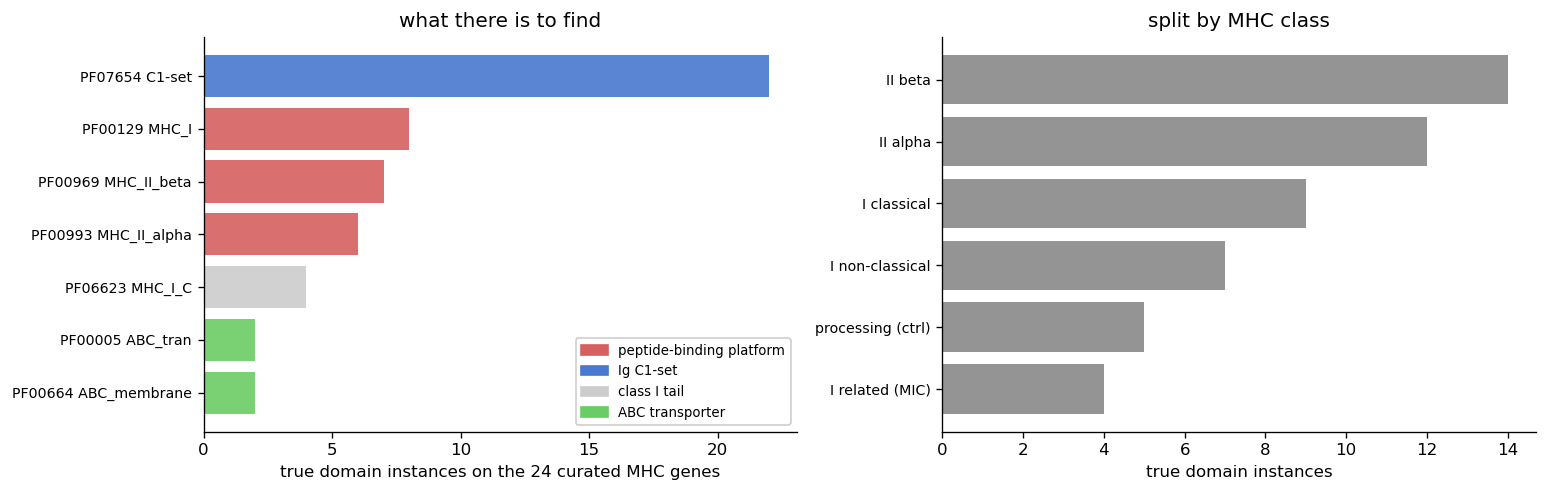

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import polars as pl

import mhc_region_utils as mu
import ortholog_analysis_utils as ou

FIG_DIR = Path("../figures")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight", "font.size": 10})

gene_map = mu.load_chr6_gene_map()
core = gene_map.filter(pl.col("mhc_class").is_not_null())
truth = mu.load_human_truth()
dl = mu.load_domain_level().with_columns(arm=pl.col("tool") + "." + pl.col("variant"))

# The 51 true (gene, family) pairs on the 24 curated MHC genes.
TRUE = (
    truth.rename({"accession": "query_acc"})
    .join(
        core.select(
            query_acc="accession", hgnc_symbol="hgnc_symbol", mhc_class="mhc_class"
        ),
        on="query_acc",
        how="inner",
    )
    .with_columns(role=mu.domain_role(pl.col("pfam_id")))
)

ARMS = [
    "hmmer3_phmmer.default",
    "hmmer3_jackhmmer.n3",
    "hhblits.single_seq",
    "mmseqs2_seqseq.s7",
    "mmseqs2_iterative.s7",
    "foldseek.3di_aa",
    "reseek.verysensitive",
    "prostt5.3di_from_seq",
    "folddisco.motif",
    "kmerseek.hp_pbotc_1st_ed2_k19_lcTrue",
]
ARM_SHORT = {a: a.split(".")[0] for a in ARMS}
ARM_SHORT["kmerseek.hp_pbotc_1st_ed2_k19_lcTrue"] = "kmerseek k19"


def recovery(species):
    # Full grid of (true domain x arm). A pair an arm never called on has no row in the
    # domain table and must be filled as "not found", not dropped -- dropping it silently
    # shrinks the denominator to only the domains the arm already found.
    grid = TRUE.join(pl.DataFrame({"arm": ARMS}), how="cross")
    got = dl.filter(pl.col("species") == species).select(
        "query_acc", "pfam_id", "arm", "found", "best_iou", "best_cover"
    )
    return grid.join(got, on=["query_acc", "pfam_id", "arm"], how="left").with_columns(
        found=pl.col("found").fill_null(False),
        best_iou=pl.col("best_iou").fill_null(0.0),
        best_cover=pl.col("best_cover").fill_null(0.0),
    )


mouse = recovery("mouse")
PFAM_NAME = mu.pfam_label(sorted(TRUE["pfam_id"].unique().to_list()))

by_role = TRUE.group_by("role").len().sort("len", descending=True)
by_fam = (
    TRUE.group_by("pfam_id", "role")
    .len()
    .with_columns(domain_len=pl.lit(0))
    .sort("len", descending=True)
)
by_fam = (
    TRUE.with_columns(dlen=pl.col("domain_end") - pl.col("domain_start") + 1)
    .group_by("pfam_id", "role")
    .agg(n=pl.len(), mean_len=pl.col("dlen").mean().round(0))
    .sort("n", descending=True)
)
print(
    f"true MHC domain instances: {TRUE.height} on {TRUE['query_acc'].n_unique()} genes"
)
print("by structural role:")
print(by_role)
print("\nby Pfam family:")
with pl.Config(tbl_rows=20, tbl_width_chars=140):
    print(
        by_fam.with_columns(
            pfam=pl.col("pfam_id").replace_strict(PFAM_NAME, default=pl.col("pfam_id"))
        )
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
b = by_fam.sort("n")
axes[0].barh(
    range(b.height),
    b["n"],
    color=[mu.DOMAIN_ROLE_COLORS[r] for r in b["role"]],
    alpha=0.9,
)
axes[0].set_yticks(range(b.height))
axes[0].set_yticklabels([PFAM_NAME[p] for p in b["pfam_id"]], fontsize=8.5)
axes[0].set_xlabel("true domain instances on the 24 curated MHC genes")
axes[0].set_title("what there is to find")
c = TRUE.group_by("mhc_class").len().sort("len")
axes[1].barh(range(c.height), c["len"], color="#888888", alpha=0.9)
axes[1].set_yticks(range(c.height))
axes[1].set_yticklabels(c["mhc_class"], fontsize=8.5)
axes[1].set_xlabel("true domain instances")
axes[1].set_title("split by MHC class")
for ax in axes:
    for s_ in ("right", "top"):
        ax.spines[s_].set_visible(False)
handles = [mpatches.Patch(color=v, label=k) for k, v in mu.DOMAIN_ROLE_COLORS.items()]
axes[0].legend(handles=handles, fontsize=8, loc="lower right", framealpha=0.95)
fig.tight_layout()
fig.savefig(FIG_DIR / "223_truth_composition.png", dpi=200)

## 1. The Ig domain is recovered by everything; the class II platform by nothing

Recovery here is the run's own definition — a call whose transferred Pfam family matches and
whose interval reaches IoU ≥ 0.5 against the true domain. Target is mouse, 100 Mya, the
easiest comparison in the run.

The class I platform (PF00129) and the class II platforms (PF00993, PF00969) are separated
because they do not behave the same way, and the reason is in §2.

One row is not on the same rule as the others. Folddisco is scored on cover rather than IoU —
`evaluate_domain_calls.py` sets `semantics = "motif" if job["tool"] == "folddisco" else
"alignment"`, read from the pipeline source rather than from a metrics file — so its
`delimited` cells answer a different question. It is held out of every IoU comparison below
and used on its own terms in §7.

mouse — domains recovered / domains present, per Pfam family (IoU ≥ 0.5):
shape: (10, 8)
┌──────────────────────────────────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┐
│ arm                                  ┆ PF00129 ┆ PF00993 ┆ PF00969 ┆ PF07654 ┆ PF06623 ┆ PF00664 ┆ PF00005 │
│ ---                                  ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     │
│ str                                  ┆ str     ┆ str     ┆ str     ┆ str     ┆ str     ┆ str     ┆ str     │
╞══════════════════════════════════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╡
│ mmseqs2_iterative.s7                 ┆ 8/8     ┆ 0/6     ┆ 0/7     ┆ 22/22   ┆ 0/4     ┆ 1/2     ┆ 2/2     │
│ reseek.verysensitive                 ┆ 8/8     ┆ 0/6     ┆ 0/7     ┆ 22/22   ┆ 0/4     ┆ 0/2     ┆ 2/2     │
│ prostt5.3di_from_seq                 ┆ 8/8     ┆ 0/6     ┆ 0/7     ┆ 22/22   ┆ 0/4     ┆ 1/2     ┆ 2/2     │
│ hmmer3_phmmer.default

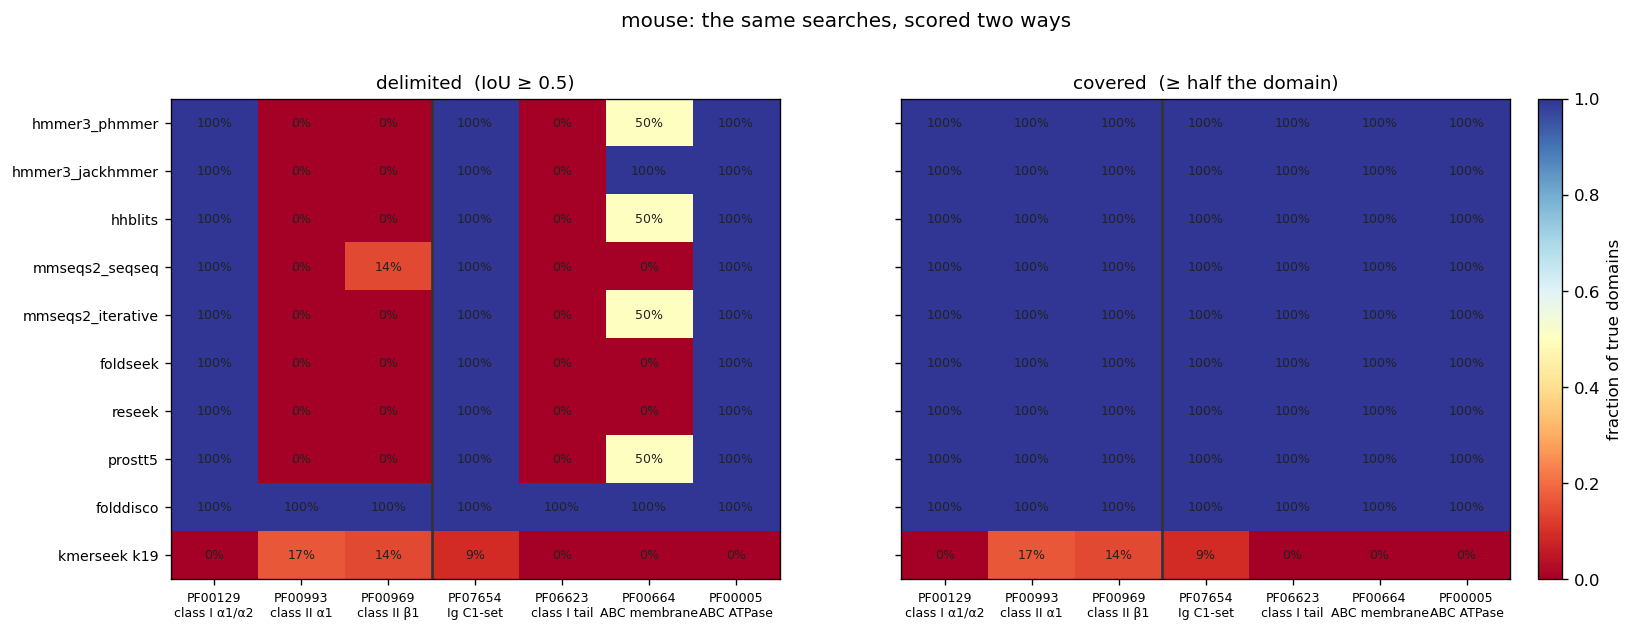

In [2]:
def by_family(frame, value):
    t = frame.group_by("arm", "pfam_id").agg(
        (
            pl.col(value).sum().alias("n")
            if value == "found"
            else pl.col(value).mean().alias("n")
        ),
        pl.len().alias("total"),
    )
    return t


fam_order = [
    "PF00129",
    "PF00993",
    "PF00969",
    "PF07654",
    "PF06623",
    "PF00664",
    "PF00005",
]
FAM_LABEL = {
    "PF00129": "PF00129\nclass I α1/α2",
    "PF00993": "PF00993\nclass II α1",
    "PF00969": "PF00969\nclass II β1",
    "PF07654": "PF07654\nIg C1-set",
    "PF06623": "PF06623\nclass I tail",
    "PF00664": "PF00664\nABC membrane",
    "PF00005": "PF00005\nABC ATPase",
}

rec = by_family(mouse, "found")
wide = rec.with_columns(
    cell=pl.col("n").cast(pl.String) + "/" + pl.col("total").cast(pl.String)
).pivot(on="pfam_id", index="arm", values="cell")
wide = wide.select(["arm"] + [f for f in fam_order if f in wide.columns])
print("mouse — domains recovered / domains present, per Pfam family (IoU ≥ 0.5):")
with pl.Config(tbl_rows=20, tbl_width_chars=190, fmt_str_lengths=45):
    print(wide)

# same table, but asking only whether the call COVERED the domain at all
cov = (
    mouse.with_columns(covered=pl.col("best_cover") >= 0.5)
    .group_by("arm", "pfam_id")
    .agg(pl.col("covered").sum().alias("n"), pl.len().alias("total"))
)
wide_c = cov.with_columns(
    cell=pl.col("n").cast(pl.String) + "/" + pl.col("total").cast(pl.String)
).pivot(on="pfam_id", index="arm", values="cell")
wide_c = wide_c.select(["arm"] + [f for f in fam_order if f in wide_c.columns])
print("\nmouse — domains COVERED (call overlaps ≥ half the domain), same searches:")
with pl.Config(tbl_rows=20, tbl_width_chars=190, fmt_str_lengths=45):
    print(wide_c)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), sharey=True)
for ax, tbl, title in [
    (axes[0], rec, "delimited  (IoU ≥ 0.5)"),
    (axes[1], cov, "covered  (≥ half the domain)"),
]:
    mat = np.full((len(ARMS), len(fam_order)), np.nan)
    for i, a in enumerate(ARMS):
        for j, f in enumerate(fam_order):
            r = tbl.filter((pl.col("arm") == a) & (pl.col("pfam_id") == f))
            if r.height:
                mat[i, j] = r["n"][0] / r["total"][0]
    im = ax.imshow(mat, cmap="RdYlBu", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(fam_order)))
    ax.set_xticklabels([FAM_LABEL[f] for f in fam_order], fontsize=7.5)
    ax.set_title(title, fontsize=11)
    for i in range(len(ARMS)):
        for j in range(len(fam_order)):
            if not np.isnan(mat[i, j]):
                ax.text(
                    j,
                    i,
                    f"{mat[i, j]:.0%}",
                    ha="center",
                    va="center",
                    fontsize=7.5,
                    color="#222222",
                )
    ax.axvline(2.5, color="#333333", lw=1.6)
axes[0].set_yticks(range(len(ARMS)))
axes[0].set_yticklabels([ARM_SHORT[a] for a in ARMS], fontsize=8.5)
fig.suptitle("mouse: the same searches, scored two ways", y=1.02)
fig.colorbar(im, ax=axes, label="fraction of true domains", fraction=0.02, pad=0.02)
fig.savefig(FIG_DIR / "223_platform_vs_ig_recovery.png", dpi=200, bbox_inches="tight")

## 2. It is not sensitivity — the region is found and the boundary is not

The two panels above disagree completely for the class II platforms: 0% delimited, 100%
covered. Those calls do land on the domain; they are simply much longer than it.

Plotting IoU against cover for every true domain makes the failure mode explicit. A domain
missed for lack of sensitivity sits at the origin. A domain found but not delimited sits at
the top-left: cover 1.0, IoU below the 0.5 line.

domains fully covered but scored as misses: 18 of 51
shape: (18, 6)
┌─────────────┬───────────────────┬─────────┬──────────────────────────┬──────────┬────────────┐
│ hgnc_symbol ┆ mhc_class         ┆ pfam_id ┆ role                     ┆ best_iou ┆ best_cover │
│ ---         ┆ ---               ┆ ---     ┆ ---                      ┆ ---      ┆ ---        │
│ str         ┆ str               ┆ str     ┆ str                      ┆ f64      ┆ f64        │
╞═════════════╪═══════════════════╪═════════╪══════════════════════════╪══════════╪════════════╡
│ TAP1        ┆ processing (ctrl) ┆ PF00664 ┆ ABC transporter          ┆ 0.459    ┆ 1.0        │
│ HLA-A       ┆ I classical       ┆ PF06623 ┆ class I tail             ┆ 0.156    ┆ 1.0        │
│ HLA-B       ┆ I classical       ┆ PF06623 ┆ class I tail             ┆ 0.099    ┆ 0.92       │
│ HLA-C       ┆ I classical       ┆ PF06623 ┆ class I tail             ┆ 0.155    ┆ 1.0        │
│ HLA-E       ┆ I non-classical   ┆ PF06623 ┆ class I tail 

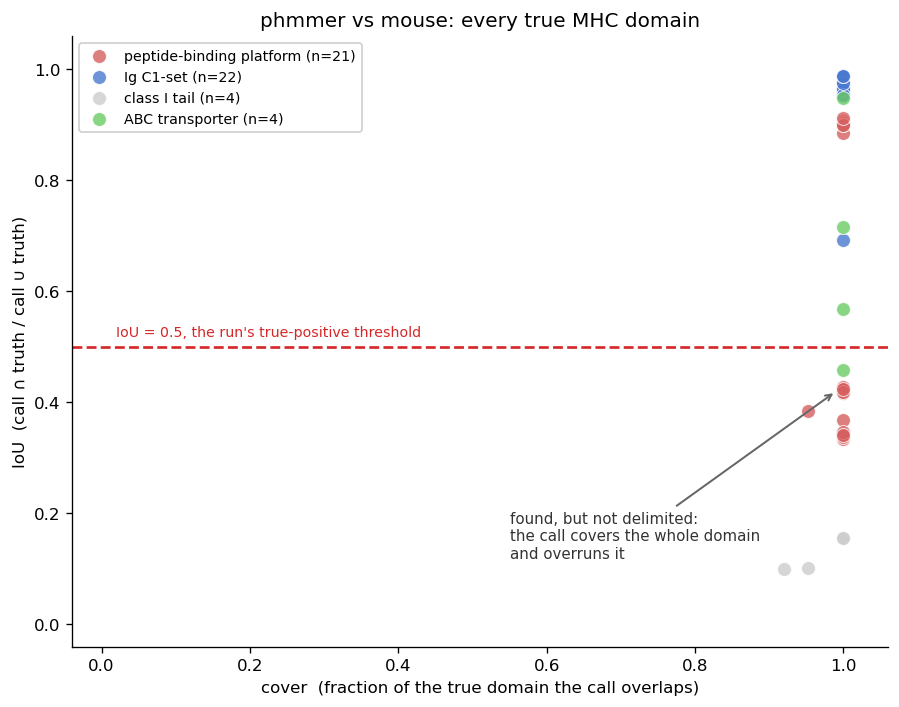

In [3]:
sub = mouse.filter(pl.col("arm") == "hmmer3_phmmer.default")
fig, ax = plt.subplots(figsize=(7.6, 6.0))
for role, colour in mu.DOMAIN_ROLE_COLORS.items():
    s = sub.filter(pl.col("role") == role)
    if s.height == 0:
        continue
    ax.scatter(
        s["best_cover"],
        s["best_iou"],
        s=70,
        color=colour,
        alpha=0.8,
        edgecolor="white",
        linewidth=0.6,
        label=f"{role} (n={s.height})",
    )
ax.axhline(0.5, color="#D62728", lw=1.6, ls="--")
ax.text(
    0.02,
    0.52,
    "IoU = 0.5, the run's true-positive threshold",
    color="#D62728",
    fontsize=8.5,
)
ax.annotate(
    "found, but not delimited:\nthe call covers the whole domain\nand overruns it",
    (0.99, 0.42),
    (0.55, 0.12),
    fontsize=9,
    color="#333333",
    arrowprops=dict(arrowstyle="->", lw=1.2, color="#666666"),
)
ax.set_xlabel("cover  (fraction of the true domain the call overlaps)")
ax.set_ylabel("IoU  (call ∩ truth / call ∪ truth)")
ax.set_title("phmmer vs mouse: every true MHC domain")
ax.set_xlim(-0.04, 1.06)
ax.set_ylim(-0.04, 1.06)
ax.legend(fontsize=8.5, loc="upper left", framealpha=0.95)
for s_ in ("right", "top"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "223_iou_vs_cover.png", dpi=200)

miss = sub.filter((pl.col("best_cover") >= 0.9) & (pl.col("best_iou") < 0.5))
print(f"domains fully covered but scored as misses: {miss.height} of {sub.height}")
with pl.Config(tbl_rows=20, tbl_width_chars=160):
    print(
        miss.select(
            "hgnc_symbol",
            "mhc_class",
            "pfam_id",
            "role",
            pl.col("best_iou").round(3),
            pl.col("best_cover").round(3),
        ).sort("role", "hgnc_symbol")
    )

## 3. Why: a domain can only be delimited if the database contains it on its own

The boundary a search reports is inherited from the target it matched. The pipeline
transfers every Pfam family annotated on a target protein onto the aligned interval, so a
full-length alignment to a mouse class II β chain transfers **both** PF00969 and PF07654
onto the same full-length interval. Against a 105-residue β1 domain inside a 266-residue
protein, that is IoU ≈ 0.4 — a miss — no matter how good the alignment is.

The Ig C1-set escapes this because the target proteome contains many proteins where a C1-set
appears **without** an MHC platform next to it. Those give short, tight alignments and a
correct boundary. The class II platforms have no such partner-free examples anywhere.

The table below is the mechanism, counted from the run's own target domain maps.

Target proteins carrying each family, and how many carry it as their ONLY family:
shape: (21, 5)
┌───────────┬─────────┬────────────┬─────────────────────┬────────────┐
│ species   ┆ pfam_id ┆ n_proteins ┆ n_carrying_it_alone ┆ frac_alone │
│ ---       ┆ ---     ┆ ---        ┆ ---                 ┆ ---        │
│ str       ┆ str     ┆ i64        ┆ i64                 ┆ f64        │
╞═══════════╪═════════╪════════════╪═════════════════════╪════════════╡
│ chicken   ┆ PF00005 ┆ 9          ┆ 0                   ┆ 0.0        │
│ chicken   ┆ PF00129 ┆ 2          ┆ 0                   ┆ 0.0        │
│ chicken   ┆ PF00664 ┆ 4          ┆ 0                   ┆ 0.0        │
│ chicken   ┆ PF00969 ┆ 3          ┆ 0                   ┆ 0.0        │
│ chicken   ┆ PF00993 ┆ 1          ┆ 0                   ┆ 0.0        │
│ chicken   ┆ PF06623 ┆ 0          ┆ 0                   ┆ null       │
│ chicken   ┆ PF07654 ┆ 11         ┆ 2                   ┆ 0.182      │
│ mouse     ┆ PF00005 ┆ 53         ┆ 1 

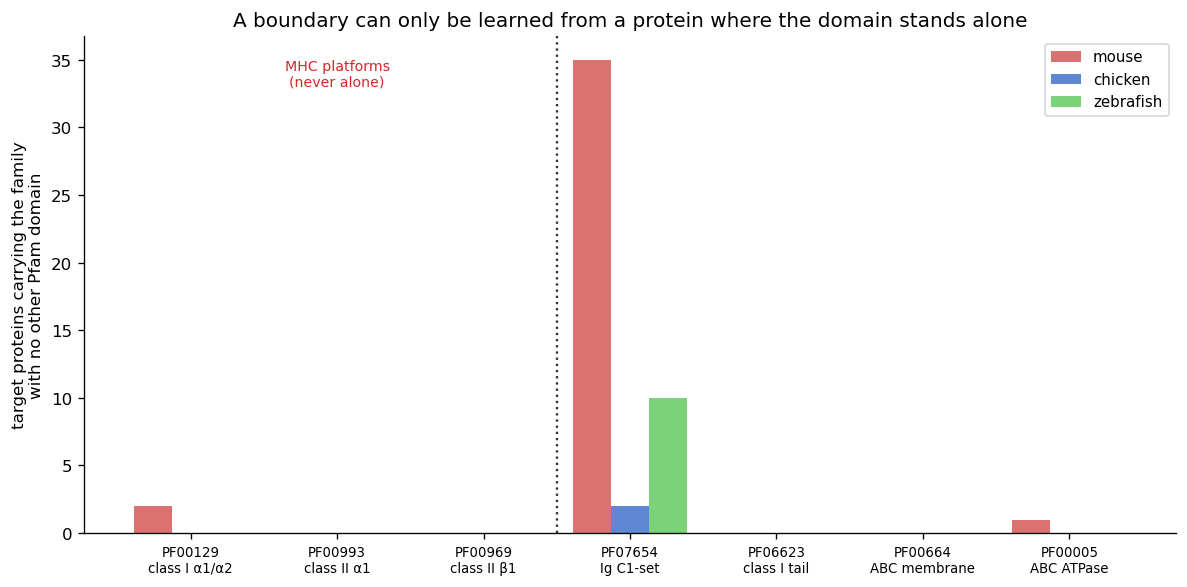

In [4]:
rows = []
for sp in ["mouse", "chicken", "zebrafish"]:
    dm = mu.load_target_domain_map(sp)
    for fam in fam_order:
        prots = dm.filter(pl.col("pfam_id") == fam)["accession"].unique().to_list()
        if len(prots) == 0:
            rows.append(
                {
                    "species": sp,
                    "pfam_id": fam,
                    "n_proteins": 0,
                    "n_carrying_it_alone": 0,
                    "frac_alone": None,
                }
            )
            continue
        s = dm.filter(pl.col("accession").is_in(prots))
        alone = (
            s.group_by("accession")
            .agg(pl.col("pfam_id").n_unique().alias("nf"))
            .filter(pl.col("nf") == 1)
            .height
        )
        rows.append(
            {
                "species": sp,
                "pfam_id": fam,
                "n_proteins": len(prots),
                "n_carrying_it_alone": alone,
                "frac_alone": round(alone / len(prots), 3),
            }
        )
occ = pl.DataFrame(rows)
print(
    "Target proteins carrying each family, and how many carry it as their ONLY family:"
)
with pl.Config(tbl_rows=40, tbl_width_chars=170):
    print(occ.sort("species", "pfam_id"))

fig, ax = plt.subplots(figsize=(10, 5.0))
x = np.arange(len(fam_order))
w = 0.26
for i, sp in enumerate(["mouse", "chicken", "zebrafish"]):
    vals = [
        occ.filter((pl.col("species") == sp) & (pl.col("pfam_id") == f))[
            "n_carrying_it_alone"
        ].sum()
        for f in fam_order
    ]
    ax.bar(
        x + (i - 1) * w,
        vals,
        w,
        label=sp,
        color=["#D65F5F", "#4878CF", "#6ACC65"][i],
        alpha=0.88,
    )
ax.set_xticks(x)
ax.set_xticklabels([FAM_LABEL[f] for f in fam_order], fontsize=8)
ax.set_ylabel("target proteins carrying the family\nwith no other Pfam domain")
ax.set_title(
    "A boundary can only be learned from a protein where the domain stands alone"
)
ax.axvline(2.5, color="#333333", lw=1.4, ls=":")
ax.text(
    1.0,
    ax.get_ylim()[1] * 0.9,
    "MHC platforms\n(never alone)",
    ha="center",
    fontsize=8.5,
    color="#D62728",
)
ax.legend(fontsize=9)
for s_ in ("right", "top"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "223_domain_cooccurrence.png", dpi=200)

## 4. The class I platform is the exception that shows the rule

Class I comes out at 100% delimited where class II comes out at 0%, and the difference is
not biological — it is how Pfam happens to carve the two molecules up.

Pfam models the class I platform as **one** family covering α1 *and* α2 together (PF00129,
~179 residues of a 365-residue protein — 49% of it). It models the class II platform as
**half** a platform, α1 alone (PF00993, ~80 aa, 31%) or β1 alone (PF00969, ~105 aa, 40%),
because in class II the two halves sit on different chains.

That fraction is the ceiling on IoU for a full-length call, and it is why the two behave
differently. PF00129 starts near the threshold and only needs a slightly tighter-than-
full-length call to clear it — and mouse supplies two proteins carrying PF00129 with no
partner, which is where such calls come from. The class II halves start well below the
threshold and mouse supplies no partner-free example of either, so no call can reach it.

Same fold, same function, same searches, opposite scores, and the difference is a modelling
convention in the truth set meeting a fixed IoU cut.

Domain length as a fraction of its protein — the ceiling on IoU for a full-length call:
shape: (7, 6)
┌─────────┬──────────────────────────┬─────────────────┬──────────────────┬─────┬─────────────────┐
│ pfam_id ┆ role                     ┆ mean_domain_len ┆ mean_protein_len ┆ n   ┆ frac_of_protein │
│ ---     ┆ ---                      ┆ ---             ┆ ---              ┆ --- ┆ ---             │
│ str     ┆ str                      ┆ f64             ┆ f64              ┆ u32 ┆ f64             │
╞═════════╪══════════════════════════╪═════════════════╪══════════════════╪═════╪═════════════════╡
│ PF00129 ┆ peptide-binding platform ┆ 179.0           ┆ 363.0            ┆ 8   ┆ 0.493           │
│ PF00969 ┆ peptide-binding platform ┆ 105.0           ┆ 265.0            ┆ 7   ┆ 0.396           │
│ PF00664 ┆ ABC transporter          ┆ 272.0           ┆ 747.0            ┆ 2   ┆ 0.364           │
│ PF00993 ┆ peptide-binding platform ┆ 80.0            ┆ 256.0            ┆ 6   ┆ 0.312           

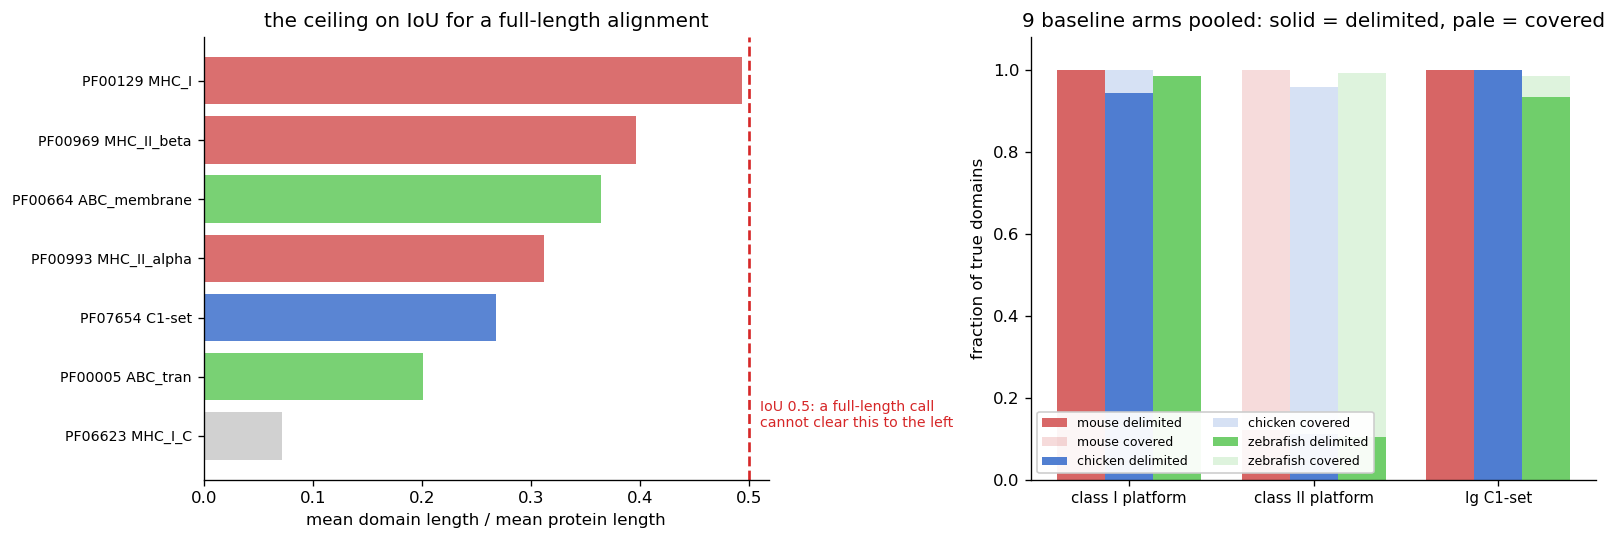

In [5]:
lens = (
    TRUE.with_columns(domain_len=pl.col("domain_end") - pl.col("domain_start") + 1)
    .group_by("pfam_id", "role")
    .agg(
        pl.col("domain_len").mean().round(0).alias("mean_domain_len"),
        pl.col("protein_length").mean().round(0).alias("mean_protein_len"),
        pl.len().alias("n"),
    )
    .with_columns(
        frac_of_protein=(pl.col("mean_domain_len") / pl.col("mean_protein_len")).round(
            3
        )
    )
)
print(
    "Domain length as a fraction of its protein — the ceiling on IoU for a full-length call:"
)
with pl.Config(tbl_rows=20, tbl_width_chars=170):
    print(lens.sort("frac_of_protein", descending=True))
print("\nA full-length alignment scores IoU = frac_of_protein. The 0.5 threshold is")
print("reachable only for families above 0.5 in that column.")

# Does this hold across every species where the platforms exist?
rows = []
for sp in ["mouse", "chicken", "zebrafish"]:
    r = recovery(sp)
    for label, expr in [
        ("class I platform", pl.col("pfam_id") == "PF00129"),
        ("class II platform", pl.col("pfam_id").is_in(["PF00993", "PF00969"])),
        ("Ig C1-set", pl.col("pfam_id") == "PF07654"),
    ]:
        s = r.filter(expr & (pl.col("arm") != "kmerseek.hp_pbotc_1st_ed2_k19_lcTrue"))
        rows.append(
            {
                "species": sp,
                "group": label,
                "delimited": round(s["found"].mean(), 3),
                "covered": round((s["best_cover"] >= 0.5).mean(), 3),
            }
        )
print()
print("Across the three species that have MHC molecules (9 baseline arms pooled):")
cross = pl.DataFrame(rows)
with pl.Config(tbl_rows=20, tbl_width_chars=160):
    print(cross)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
L = lens.sort("frac_of_protein")
axes[0].barh(
    range(L.height),
    L["frac_of_protein"],
    color=[mu.DOMAIN_ROLE_COLORS[r] for r in L["role"]],
    alpha=0.9,
)
axes[0].axvline(0.5, color="#D62728", lw=1.6, ls="--")
axes[0].text(
    0.51,
    0.15,
    "IoU 0.5: a full-length call\ncannot clear this to the left",
    color="#D62728",
    fontsize=8.5,
)
axes[0].set_yticks(range(L.height))
axes[0].set_yticklabels([PFAM_NAME[p] for p in L["pfam_id"]], fontsize=8.5)
axes[0].set_xlabel("mean domain length / mean protein length")
axes[0].set_title("the ceiling on IoU for a full-length alignment")

groups = ["class I platform", "class II platform", "Ig C1-set"]
x = np.arange(len(groups))
w = 0.26
for i, sp in enumerate(["mouse", "chicken", "zebrafish"]):
    dv = [
        cross.filter((pl.col("species") == sp) & (pl.col("group") == g))["delimited"][0]
        for g in groups
    ]
    cv = [
        cross.filter((pl.col("species") == sp) & (pl.col("group") == g))["covered"][0]
        for g in groups
    ]
    colour = ["#D65F5F", "#4878CF", "#6ACC65"][i]
    axes[1].bar(
        x + (i - 1) * w, dv, w, color=colour, alpha=0.95, label=f"{sp} delimited"
    )
    axes[1].bar(
        x + (i - 1) * w,
        cv,
        w,
        color=colour,
        alpha=0.22,
        zorder=0,
        label=f"{sp} covered",
    )
axes[1].set_xticks(x)
axes[1].set_xticklabels(groups, fontsize=9)
axes[1].set_ylabel("fraction of true domains")
axes[1].set_ylim(0, 1.08)
axes[1].set_title("9 baseline arms pooled: solid = delimited, pale = covered")
axes[1].legend(fontsize=7.5, ncol=2, loc="lower left", framealpha=0.95)
for ax in axes:
    for s_ in ("right", "top"):
        ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "223_domain_length_ceiling.png", dpi=200)

## 5. One mechanism, two conditions

Sections 3 and 4 gave two separate-sounding explanations. They are one.

IoU of a call against a domain is (call ∩ truth) / (call ∪ truth). For a call that spans the
whole protein, the union is the protein and the intersection is the domain, so the IoU is
exactly the domain's length fraction, d/L. That is not "a ceiling" in some loose sense; it is
the value. A full-length call scores d/L and nothing else.

So a domain can be delimited at IoU ≥ 0.5 only if one of two things holds.

**Condition 1 — the domain occupies at least half its protein.** Then even a full-length call
clears the cut, and nothing about the target database matters.

**Condition 2 — some target the search matched has an extent close to the domain's.** The
call inherits its query interval from the alignment, and the alignment cannot run past the
end of the target. A target carrying the family with no other domain beside it is the clean
case of this. It is not the only case, which §6 shows.

The table below puts both conditions next to the outcome. No MHC family satisfies condition 1
— PF00129 comes closest at 0.49 and still falls short — so every delimited MHC domain in this
run got there through condition 2.

One row already strains the strict reading of condition 2. PF00664, the ABC membrane domain of
TAP1 and TAP2, has no single-domain mouse target and is still delimited in 37% of the pooled
arm-domain cells. Either condition 2 is stated too narrowly or something else is going on.
Section 6 removes the targets and finds out which.

Condition 1 = length fraction ≥ 0.5.  Condition 2 = ≥ 1 mouse target carries the
family with no other Pfam domain.  Outcome pooled over the 8 IoU-scored arms.

shape: (7, 9)
┌─────────┬──────────────────────────┬─────────┬─────────────────┬───┬───────────────────┬─────────┬───────┬────────────┐
│ pfam_id ┆ role                     ┆ n_truth ┆ length_fraction ┆ … ┆ n_target_proteins ┆ n_alone ┆ cond2 ┆ delim_rate │
│ ---     ┆ ---                      ┆ ---     ┆ ---             ┆   ┆ ---               ┆ ---     ┆ ---   ┆ ---        │
│ str     ┆ str                      ┆ u32     ┆ f64             ┆   ┆ u32               ┆ u32     ┆ bool  ┆ f64        │
╞═════════╪══════════════════════════╪═════════╪═════════════════╪═══╪═══════════════════╪═════════╪═══════╪════════════╡
│ PF00129 ┆ peptide-binding platform ┆ 8       ┆ 0.491           ┆ … ┆ 37                ┆ 2       ┆ true  ┆ 1.0        │
│ PF00969 ┆ peptide-binding platform ┆ 7       ┆ 0.391           ┆ … ┆ 9                 ┆ 0  

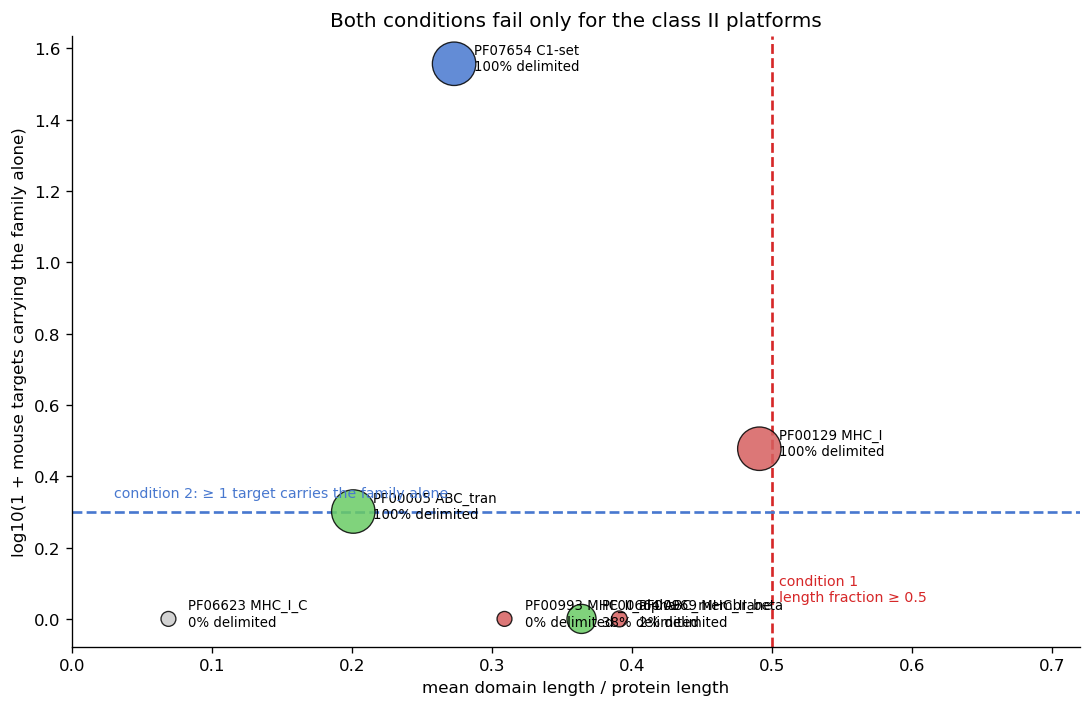

In [6]:
mouse_map = mu.load_target_domain_map("mouse")
n_families_on_target = mouse_map.group_by("accession").agg(
    nf=pl.col("pfam_id").n_unique()
)
alone = (
    mouse_map.join(n_families_on_target, on="accession")
    .filter(pl.col("nf") == 1)
    .group_by("pfam_id")
    .agg(n_alone=pl.col("accession").n_unique())
)
carried = mouse_map.group_by("pfam_id").agg(
    n_target_proteins=pl.col("accession").n_unique()
)

frac = (
    TRUE.with_columns(
        f=(pl.col("domain_end") - pl.col("domain_start")) / pl.col("protein_length")
    )
    .group_by("pfam_id", "role")
    .agg(n_truth=pl.len(), length_fraction=pl.col("f").mean().round(3))
)

# The run's own outcome, with Folddisco held out: it is scored on cover rather than IoU
# (evaluate_domain_calls.py line 1409), so putting it in an IoU column would mix two rules.
IOU_ARMS = [a for a in ARMS if not a.startswith(("folddisco", "kmerseek"))]
outcome = (
    mouse.filter(pl.col("arm").is_in(IOU_ARMS))
    .group_by("pfam_id")
    .agg(delimited_arm_cells=pl.col("found").sum(), cells=pl.len())
    .with_columns(delim_rate=(pl.col("delimited_arm_cells") / pl.col("cells")).round(3))
)

COND = (
    frac.join(carried, on="pfam_id", how="left")
    .join(alone, on="pfam_id", how="left")
    .join(outcome, on="pfam_id", how="left")
    .with_columns(
        n_target_proteins=pl.col("n_target_proteins").fill_null(0),
        n_alone=pl.col("n_alone").fill_null(0),
    )
    .with_columns(cond1=pl.col("length_fraction") >= 0.5, cond2=pl.col("n_alone") > 0)
    .sort("length_fraction", descending=True)
)
print(
    "Condition 1 = length fraction ≥ 0.5.  Condition 2 = ≥ 1 mouse target carries the"
)
print(
    f"family with no other Pfam domain.  Outcome pooled over the {len(IOU_ARMS)} IoU-scored arms.\n"
)
with pl.Config(tbl_rows=20, tbl_width_chars=200):
    print(
        COND.select(
            "pfam_id",
            "role",
            "n_truth",
            "length_fraction",
            "cond1",
            "n_target_proteins",
            "n_alone",
            "cond2",
            "delim_rate",
        )
    )

fig, ax = plt.subplots(figsize=(9.2, 6.0))
xs = COND["length_fraction"].to_numpy()
ys = np.log10(COND["n_alone"].to_numpy() + 1)
sizes = 80 + 600 * COND["delim_rate"].to_numpy()
ax.scatter(
    xs,
    ys,
    s=sizes,
    c=[mu.DOMAIN_ROLE_COLORS[r] for r in COND["role"]],
    alpha=0.85,
    edgecolor="black",
    linewidth=0.8,
    zorder=3,
)
for x, y, p, d in zip(xs, ys, COND["pfam_id"], COND["delim_rate"]):
    ax.annotate(
        f"{PFAM_NAME[p]}\n{d:.0%} delimited",
        (x, y),
        textcoords="offset points",
        xytext=(12, -4),
        fontsize=8,
    )
ax.axvline(0.5, color="#D62728", lw=1.6, ls="--")
ax.axhline(np.log10(2), color="#4878CF", lw=1.6, ls="--")
ax.text(
    0.505, 0.05, "condition 1\nlength fraction ≥ 0.5", color="#D62728", fontsize=8.5
)
ax.text(
    0.03,
    np.log10(2) + 0.04,
    "condition 2: ≥ 1 target carries the family alone",
    color="#4878CF",
    fontsize=8.5,
)
ax.set_xlabel("mean domain length / protein length")
ax.set_ylabel("log10(1 + mouse targets carrying the family alone)")
ax.set_title("Both conditions fail only for the class II platforms")
ax.set_xlim(0, 0.72)
for s_ in ("right", "top"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "223_two_conditions.png", dpi=200)

## 6. The ablation: take the single-domain targets away

Section 5 is a story that fits the numbers. The way to find out whether it is the mechanism
is to remove the thing it names and see whether the effect goes with it.

The prediction is explicit. PF00129 fails condition 1 (0.49) and passes condition 2 on two
mouse proteins, P14431 and V9GXR0, which carry a class I α1/α2 domain and nothing else.
Remove those two proteins from the target set and class I platform recall should collapse
toward zero, exactly as class II does.

Doing that needs a target accession per call, which the collapsed call table does not carry.
The region tables do: `mu.BASELINE_REGIONS` has `query_acc`, `target_acc` and both the query
and target intervals. So the calls are rebuilt here from the regions, using the pipeline's own
two steps — transfer every target Pfam domain the region covers to at least half its length,
then score the query interval against the human truth — and the rebuild is checked against the
run's own numbers before anything is ablated.

single-domain PF00129 mouse targets removed: ['P14431', 'V9GXR0']

Rebuilt from regions, full target set (this should match §1):
shape: (9, 8)
┌───────────────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┐
│ tool              ┆ PF00129 ┆ PF00993 ┆ PF00969 ┆ PF07654 ┆ PF06623 ┆ PF00664 ┆ PF00005 │
│ ---               ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     │
│ str               ┆ u32     ┆ u32     ┆ u32     ┆ u32     ┆ u32     ┆ u32     ┆ u32     │
╞═══════════════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╪═════════╡
│ folddisco         ┆ 8       ┆ 6       ┆ 7       ┆ 22      ┆ 4       ┆ 2       ┆ 2       │
│ foldseek          ┆ 8       ┆ 0       ┆ 0       ┆ 22      ┆ 0       ┆ 0       ┆ 2       │
│ hhblits           ┆ 8       ┆ 0       ┆ 0       ┆ 22      ┆ 0       ┆ 1       ┆ 2       │
│ hmmer3_jackhmmer  ┆ 8       ┆ 0       ┆ 0       ┆ 22      ┆ 0       ┆ 2       ┆ 2       │
│ hmmer3_phmmer     ┆ 8      

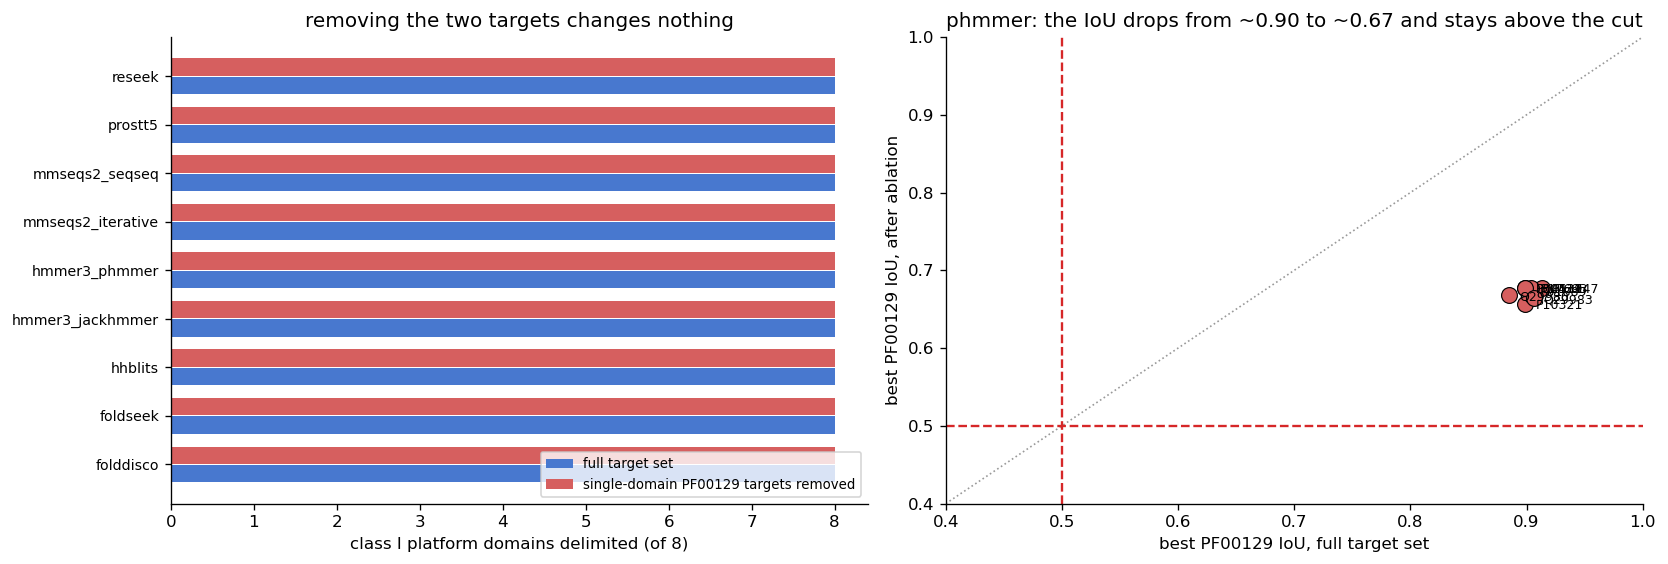

In [7]:
def _ov(a0, a1, b0, b1):
    return (pl.min_horizontal(a1, b1) - pl.max_horizontal(a0, b0)).clip(lower_bound=0)


def rebuild_calls(
    regions: pl.LazyFrame, domain_map: pl.DataFrame, min_overlap: float = 0.5
) -> pl.DataFrame:
    # transfer_domains(): a region carries every target-side family whose domain it covers
    # to at least min_overlap of that domain's length.
    j = (
        regions.join(
            domain_map.lazy().select(
                target_acc="accession",
                pfam_id="pfam_id",
                t_dom_start="domain_start",
                t_dom_end="domain_end",
            ),
            on="target_acc",
            how="inner",
        )
        .with_columns(
            t_overlap=_ov("tstart", "tend", "t_dom_start", "t_dom_end"),
            t_dom_len=pl.col("t_dom_end") - pl.col("t_dom_start"),
        )
        .filter(pl.col("t_overlap") >= min_overlap * pl.col("t_dom_len"))
    )
    # score_calls(): IoU and cover of the QUERY interval against the human truth. The null
    # branch is load-bearing -- polars' horizontal min/max skip nulls, so a family the query
    # does not have would otherwise come out at IoU 1.0.
    m = (
        j.join(
            truth.lazy().select(
                query_acc="accession",
                pfam_id="pfam_id",
                true_start="domain_start",
                true_end="domain_end",
            ),
            on=["query_acc", "pfam_id"],
            how="left",
        )
        .with_columns(o=_ov("qstart", "qend", "true_start", "true_end"))
        .with_columns(
            iou=pl.when(pl.col("true_start").is_null())
            .then(pl.lit(0.0))
            .otherwise(
                pl.col("o")
                / (
                    pl.max_horizontal("qend", "true_end")
                    - pl.min_horizontal("qstart", "true_start")
                )
            )
            .fill_null(0.0),
            cover=pl.when(pl.col("true_start").is_null())
            .then(pl.lit(0.0))
            .otherwise(pl.col("o") / (pl.col("true_end") - pl.col("true_start")))
            .fill_null(0.0),
        )
    )
    return (
        m.group_by("tool", "query_acc", "pfam_id")
        .agg(
            best_iou=pl.col("iou").max(),
            best_cover=pl.col("cover").max(),
            n_calls=pl.len(),
        )
        .collect()
    )


CORE_ACC = TRUE["query_acc"].unique().to_list()
regions = (
    pl.scan_parquet(mu.BASELINE_REGIONS)
    .filter((pl.col("species") == "mouse") & pl.col("query_acc").is_in(CORE_ACC))
    .select(
        "tool", "query_acc", "target_acc", "qstart", "qend", "tstart", "tend", "score"
    )
)
BASE_TOOLS = regions.select("tool").unique().collect()["tool"].to_list()
CGRID = TRUE.select("query_acc", "pfam_id", "role").join(
    pl.DataFrame({"tool": BASE_TOOLS}), how="cross"
)


def delimited_table(calls, label):
    # Folddisco is scored on cover, every other tool on IoU -- the pipeline's own per-tool
    # rule. Mixing them into one column would be the metric-shopping this notebook warns about.
    g = CGRID.join(calls, on=["tool", "query_acc", "pfam_id"], how="left").with_columns(
        best_iou=pl.col("best_iou").fill_null(0.0),
        best_cover=pl.col("best_cover").fill_null(0.0),
    )
    key = (
        pl.when(pl.col("tool") == "folddisco")
        .then(pl.col("best_cover"))
        .otherwise(pl.col("best_iou"))
    )
    return (
        g.with_columns(hit=key >= 0.5, run=pl.lit(label))
        .group_by("run", "tool", "pfam_id")
        .agg(delimited=pl.col("hit").sum())
    )


ALONE_129 = (
    mouse_map.join(n_families_on_target, on="accession")
    .filter((pl.col("pfam_id") == "PF00129") & (pl.col("nf") == 1))["accession"]
    .unique()
    .to_list()
)
full_calls = rebuild_calls(regions, mouse_map)
abl_calls = rebuild_calls(
    regions.filter(~pl.col("target_acc").is_in(ALONE_129)), mouse_map
)

full_t = delimited_table(full_calls, "full target set")
abl_t = delimited_table(abl_calls, "PF00129 single-domain targets removed")
print(f"single-domain PF00129 mouse targets removed: {ALONE_129}")
print("\nRebuilt from regions, full target set (this should match §1):")
with pl.Config(tbl_rows=20, tbl_width_chars=190):
    print(
        full_t.pivot(on="pfam_id", index="tool", values="delimited")
        .select(["tool"] + [f for f in fam_order])
        .sort("tool")
    )
print("\nAfter removing the two single-domain PF00129 targets:")
with pl.Config(tbl_rows=20, tbl_width_chars=190):
    print(
        abl_t.pivot(on="pfam_id", index="tool", values="delimited")
        .select(["tool"] + [f for f in fam_order])
        .sort("tool")
    )


# Where the best PF00129 call comes from, before and after.
def best_129(regs):
    j = (
        regs.join(
            mouse_map.lazy().select(
                target_acc="accession",
                pfam_id="pfam_id",
                ts="domain_start",
                te="domain_end",
            ),
            on="target_acc",
            how="inner",
        )
        .filter(pl.col("pfam_id") == "PF00129")
        .with_columns(
            to=_ov("tstart", "tend", "ts", "te"), tl=pl.col("te") - pl.col("ts")
        )
        .filter(pl.col("to") >= 0.5 * pl.col("tl"))
        .join(
            truth.lazy().select(
                query_acc="accession",
                pfam_id="pfam_id",
                tst="domain_start",
                ten="domain_end",
                plen="protein_length",
            ),
            on=["query_acc", "pfam_id"],
            how="inner",
        )
        .with_columns(o=_ov("qstart", "qend", "tst", "ten"))
        .with_columns(
            iou=pl.col("o")
            / (pl.max_horizontal("qend", "ten") - pl.min_horizontal("qstart", "tst"))
        )
    )
    return (
        j.filter(pl.col("tool") == "hmmer3_phmmer")
        .collect()
        .sort("iou", descending=True)
        .group_by("query_acc")
        .agg(pl.all().first())
        .with_columns(call_frac=(pl.col("qend") - pl.col("qstart")) / pl.col("plen"))
    )


b_full = best_129(regions).select(
    "query_acc",
    "target_acc",
    pl.col("iou").round(3).alias("iou_full"),
    pl.col("call_frac").round(3).alias("call_frac_full"),
)
b_abl = best_129(regions.filter(~pl.col("target_acc").is_in(ALONE_129))).select(
    "query_acc",
    target_acc_abl="target_acc",
    iou_abl=pl.col("iou").round(3),
    call_frac_abl=pl.col("call_frac").round(3),
)
cmp = b_full.join(b_abl, on="query_acc", how="left").sort("query_acc")
print("\nphmmer's best PF00129 call per class I gene, before and after the ablation:")
with pl.Config(tbl_rows=20, tbl_width_chars=190):
    print(cmp)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
both_t = pl.concat([full_t, abl_t])
p129 = (
    both_t.filter(pl.col("pfam_id") == "PF00129")
    .pivot(on="run", index="tool", values="delimited")
    .sort("tool")
)
y = np.arange(p129.height)
axes[0].barh(
    y - 0.19, p129["full target set"], 0.36, color="#4878CF", label="full target set"
)
axes[0].barh(
    y + 0.19,
    p129["PF00129 single-domain targets removed"],
    0.36,
    color="#D65F5F",
    label="single-domain PF00129 targets removed",
)
axes[0].set_yticks(y)
axes[0].set_yticklabels(p129["tool"], fontsize=8.5)
axes[0].set_xlabel("class I platform domains delimited (of 8)")
axes[0].set_title("removing the two targets changes nothing")
axes[0].legend(fontsize=8, loc="lower right")
axes[1].scatter(
    cmp["iou_full"],
    cmp["iou_abl"],
    s=90,
    color="#D65F5F",
    edgecolor="black",
    linewidth=0.7,
    zorder=3,
)
axes[1].plot([0, 1], [0, 1], color="#999999", lw=1.0, ls=":")
axes[1].axhline(0.5, color="#D62728", lw=1.4, ls="--")
axes[1].axvline(0.5, color="#D62728", lw=1.4, ls="--")
for r in cmp.iter_rows(named=True):
    axes[1].annotate(
        r["query_acc"],
        (r["iou_full"], r["iou_abl"]),
        textcoords="offset points",
        xytext=(6, -3),
        fontsize=7.5,
    )
axes[1].set_xlabel("best PF00129 IoU, full target set")
axes[1].set_ylabel("best PF00129 IoU, after ablation")
axes[1].set_xlim(0.4, 1.0)
axes[1].set_ylim(0.4, 1.0)
axes[1].set_title("phmmer: the IoU drops from ~0.90 to ~0.67 and stays above the cut")
for ax in axes:
    for s_ in ("right", "top"):
        ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "223_ablation_pf00129.png", dpi=200)

The prediction is wrong, and being wrong is informative.

Removing P14431 and V9GXR0 leaves class I platform recall at 8 of 8 for every one of the nine
tools. Nothing collapses. So condition 2 is not carried by single-domain targets alone.

What the ablation does move is where the call comes from and how good it is. With the full
target set, phmmer's best PF00129 call on all eight class I genes is transferred from P14431
or V9GXR0, and it lands at IoU 0.89–0.91 spanning about 54% of the query. With those two gone,
the best call comes instead from Q8HWE5, Q8HWE7, Q85ZW9 or F7CXU4 at IoU 0.62–0.68. Those are
ordinary two-domain class I chains, but short ones: their annotated PF00129 plus C1-set ends
between residues 288 and 324 of a 329–395 residue protein, so the alignment stops there and the
transferred call spans 72–74% of the query instead of all of it.

Condition 2 is therefore about target *extent*, not target *architecture*. A call is delimited
when some matched target's aligned extent is close to the domain's extent, and a single-domain
target is the cleanest way to get that but not the only one. Any truncated or partially
aligned target does the same job. What the class II platforms lack is not specifically a
single-domain target but any target whose aligned extent stops near the end of an 80–105
residue platform: every mouse class II chain is a compact ~250-residue protein whose platform
and C1-set are adjacent, so the alignment covers both or neither.

The second ablation, below, tests the refined statement on the family where condition 1 is
furthest from being met.

single-domain PF07654 mouse targets removed: 35
PF07654 length fraction is 0.276, so condition 1 cannot rescue it.

Ig C1-set domains delimited (of 22), before and after:
shape: (9, 4)
┌───────────────────┬─────────────────┬─────────────────────────────────┬──────┐
│ tool              ┆ full target set ┆ PF07654 single-domain targets … ┆ lost │
│ ---               ┆ ---             ┆ ---                             ┆ ---  │
│ str               ┆ u32             ┆ u32                             ┆ u32  │
╞═══════════════════╪═════════════════╪═════════════════════════════════╪══════╡
│ folddisco         ┆ 22              ┆ 22                              ┆ 0    │
│ foldseek          ┆ 22              ┆ 15                              ┆ 7    │
│ hhblits           ┆ 22              ┆ 22                              ┆ 0    │
│ hmmer3_jackhmmer  ┆ 22              ┆ 22                              ┆ 0    │
│ hmmer3_phmmer     ┆ 22              ┆ 22                              ┆ 0    │
│ mms

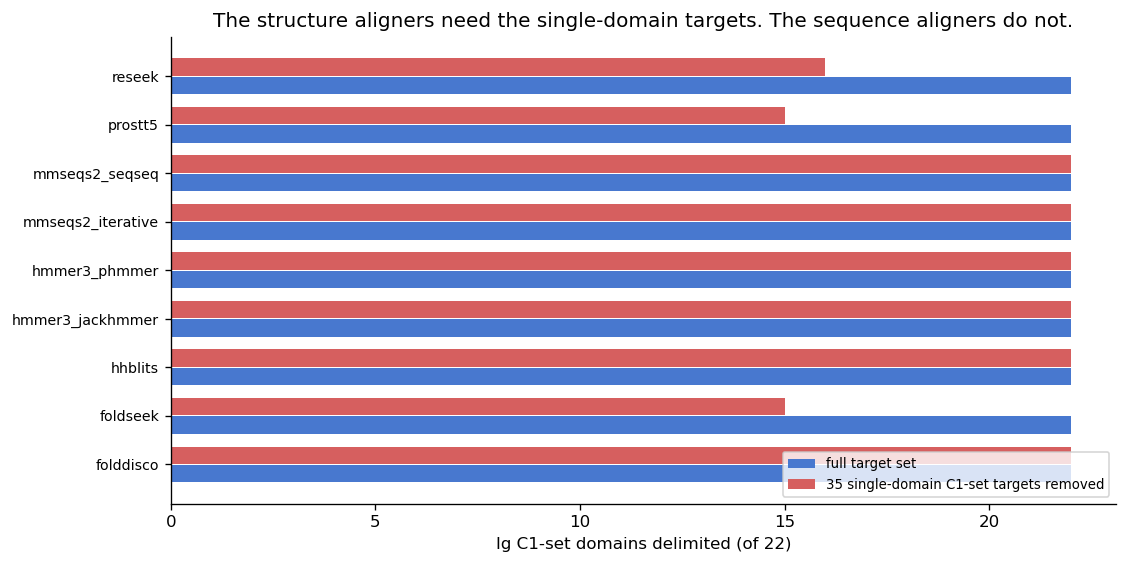

In [8]:
ALONE_7654 = (
    mouse_map.join(n_families_on_target, on="accession")
    .filter((pl.col("pfam_id") == "PF07654") & (pl.col("nf") == 1))["accession"]
    .unique()
    .to_list()
)
abl7_calls = rebuild_calls(
    regions.filter(~pl.col("target_acc").is_in(ALONE_7654)), mouse_map
)
abl7_t = delimited_table(abl7_calls, "PF07654 single-domain targets removed")
print(f"single-domain PF07654 mouse targets removed: {len(ALONE_7654)}")
print("PF07654 length fraction is 0.276, so condition 1 cannot rescue it.\n")

p7 = (
    pl.concat([full_t, abl7_t])
    .filter(pl.col("pfam_id") == "PF07654")
    .pivot(on="run", index="tool", values="delimited")
    .sort("tool")
)
p7 = p7.with_columns(
    lost=pl.col("full target set") - pl.col("PF07654 single-domain targets removed")
)
print("Ig C1-set domains delimited (of 22), before and after:")
with pl.Config(tbl_rows=20, tbl_width_chars=190):
    print(p7)
print("\nSemantics per tool: Folddisco on cover, the other eight on IoU.")

fig, ax = plt.subplots(figsize=(9.5, 4.8))
y = np.arange(p7.height)
ax.barh(y - 0.19, p7["full target set"], 0.36, color="#4878CF", label="full target set")
ax.barh(
    y + 0.19,
    p7["PF07654 single-domain targets removed"],
    0.36,
    color="#D65F5F",
    label=f"{len(ALONE_7654)} single-domain C1-set targets removed",
)
ax.set_yticks(y)
ax.set_yticklabels(p7["tool"], fontsize=8.5)
ax.set_xlabel("Ig C1-set domains delimited (of 22)")
ax.set_title(
    "The structure aligners need the single-domain targets. "
    "The sequence aligners do not."
)
ax.legend(fontsize=8, loc="lower right")
for s_ in ("right", "top"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "223_ablation_pf07654.png", dpi=200)

This one splits the tools, which is the clearest evidence in the notebook that the mechanism
is about the target's extent.

Removing the 35 mouse proteins that carry a C1-set with no other domain costs Foldseek 7 of
its 22, ProstT5 7 of 22 and Reseek 6 of 22. It costs phmmer, jackhmmer, HHblits, both MMseqs2
modes and Folddisco nothing at all.

That is exactly the split the refined statement predicts. Foldseek, ProstT5 and Reseek align
whole chains, so their query interval is the whole target's extent and the only way to get a
tight C1-set boundary is to match a target that *is* a C1-set. The sequence aligners produce
local alignments and can stop at the domain edge on a multi-domain target, so they do not need
the single-domain proteins.

Neither ablation rescues the class II platforms, and neither was expected to. They fail
because nothing in the mouse proteome — single-domain, truncated or locally alignable — has an
extent that stops at the end of a class II platform.

## 7. Folddisco is the control, not the contaminant

Folddisco is scored differently from every other arm in this run. `evaluate_domain_calls.py`
sets `semantics = "motif" if job["tool"] == "folddisco" else "alignment"`, and that switches
the true-positive test from IoU ≥ 0.5 to cover ≥ 0.5. It is the right choice for a motif
matcher, whose output is not meant to delimit anything.

It also makes Folddisco an independent test of this notebook's claim. The claim is that the
class II platform is *found* and not *delimited*, and that the 0/13 is produced by the metric
rather than by the search. Folddisco runs the same queries against the same targets and is
scored by the other rule. If the claim is right, Folddisco should recover the class II
platforms that the IoU-scored arms cannot — and it does, 13 of 13, with a tool nobody here
wrote and a rule nobody here chose.

Folddisco stays out of every IoU ranking in this notebook, because comparing a cover-scored
arm against IoU-scored arms on one axis would be exactly the metric-shopping §1–§6 warn about.
The pooled counts are broken out per tool below so it is visible that nothing in the pooled
numbers is carried by Folddisco.

Mouse, 21 platform domains. Same searches, both rules, per tool:
shape: (9, 5)
┌───────────────────┬─────────────────┬─────────────────┬───────────────────┬─────┐
│ tool              ┆ rule            ┆ platform_by_iou ┆ platform_by_cover ┆ n   │
│ ---               ┆ ---             ┆ ---             ┆ ---               ┆ --- │
│ str               ┆ str             ┆ u32             ┆ u32               ┆ u32 │
╞═══════════════════╪═════════════════╪═════════════════╪═══════════════════╪═════╡
│ folddisco         ┆ cover (motif)   ┆ 6               ┆ 21                ┆ 21  │
│ hhblits           ┆ IoU (alignment) ┆ 8               ┆ 21                ┆ 21  │
│ reseek            ┆ IoU (alignment) ┆ 8               ┆ 21                ┆ 21  │
│ prostt5           ┆ IoU (alignment) ┆ 8               ┆ 21                ┆ 21  │
│ mmseqs2_seqseq    ┆ IoU (alignment) ┆ 9               ┆ 21                ┆ 21  │
│ hmmer3_phmmer     ┆ IoU (alignment) ┆ 8               ┆ 21                ┆ 21 

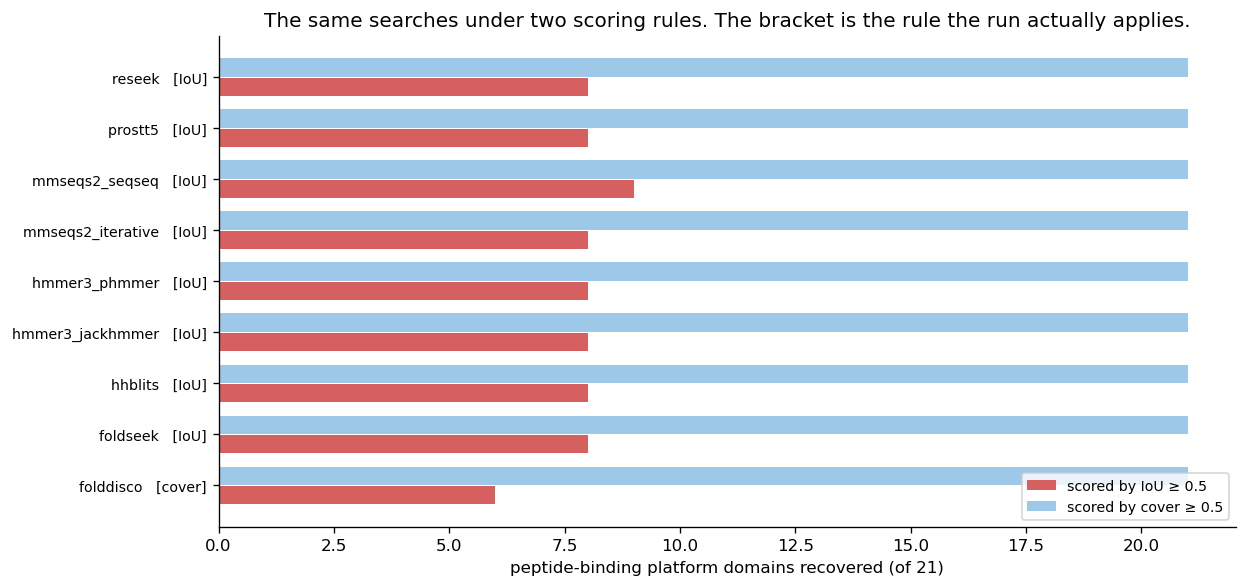

In [9]:
sem = CGRID.join(
    full_calls, on=["tool", "query_acc", "pfam_id"], how="left"
).with_columns(
    best_iou=pl.col("best_iou").fill_null(0.0),
    best_cover=pl.col("best_cover").fill_null(0.0),
)
comp = (
    sem.group_by("tool", "pfam_id")
    .agg(
        by_iou=(pl.col("best_iou") >= 0.5).sum(),
        by_cover=(pl.col("best_cover") >= 0.5).sum(),
        n=pl.len(),
    )
    .with_columns(
        rule=pl.when(pl.col("tool") == "folddisco")
        .then(pl.lit("cover (motif)"))
        .otherwise(pl.lit("IoU (alignment)"))
    )
)
plat = ["PF00129", "PF00993", "PF00969"]
tot = (
    comp.filter(pl.col("pfam_id").is_in(plat))
    .group_by("tool", "rule")
    .agg(
        platform_by_iou=pl.col("by_iou").sum(),
        platform_by_cover=pl.col("by_cover").sum(),
        n=pl.col("n").sum(),
    )
    .sort("platform_by_cover", descending=True)
)
print("Mouse, 21 platform domains. Same searches, both rules, per tool:")
with pl.Config(tbl_rows=20, tbl_width_chars=190):
    print(tot)

cls2 = (
    comp.filter(pl.col("pfam_id").is_in(["PF00993", "PF00969"]))
    .group_by("tool")
    .agg(by_iou=pl.col("by_iou").sum(), by_cover=pl.col("by_cover").sum())
    .sort("tool")
)
print("\nClass II platforms only (13 domains). Per-tool breakdown, so a pooled number")
print("cannot hide behind Folddisco:")
with pl.Config(tbl_rows=20, tbl_width_chars=190):
    print(cls2)
print(
    f"\nPooled over the 8 IoU-scored tools: {cls2.filter(pl.col('tool') != 'folddisco')['by_iou'].sum()}"
    f" of {8 * 13} tool-domain cells delimited."
)
print(
    f"Folddisco alone, on its own cover rule: {cls2.filter(pl.col('tool') == 'folddisco')['by_cover'][0]} of 13."
)

fig, ax = plt.subplots(figsize=(10.5, 5.0))
t = tot.sort("tool")
y = np.arange(t.height)
ax.barh(
    y - 0.19, t["platform_by_iou"], 0.36, color="#D65F5F", label="scored by IoU ≥ 0.5"
)
ax.barh(
    y + 0.19,
    t["platform_by_cover"],
    0.36,
    color="#9EC8E8",
    label="scored by cover ≥ 0.5",
)
ax.set_yticks(y)
ax.set_yticklabels(
    [f"{n}   [{r.split()[0]}]" for n, r in zip(t["tool"], t["rule"])], fontsize=8.5
)
ax.set_xlabel("peptide-binding platform domains recovered (of 21)")
ax.set_title(
    "The same searches under two scoring rules. The bracket is the rule the run "
    "actually applies."
)
ax.legend(fontsize=8.5, loc="lower right")
for s_ in ("right", "top"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "223_folddisco_control.png", dpi=200)

## 8. Does the HP alphabet hold the platform better than a plain amino-acid alphabet?

Sections 1-7 used one kmerseek arm alongside the nine baselines. The question this notebook
exists for is narrower: inside one molecule, with the fast-evolving platform and the
conserved Ig domain searched by the same arm against the same target, does encoding the
query as hydrophobic/polar hold the platform better than encoding it as 20 amino acids?

`protein20_k10` is the control. It is kmerseek with no alphabet reduction at all, so the
only thing that differs between it and `hp_pbotc_1st_ed2_k19` is the encoding. `dayhoff6`
and `funcgroups8` sit between the two in how much they compress.

The domain tables the earlier sections read do not carry `protein20` — only 291 of the 404
kmerseek variants survive into `mhc_domain_level_all_arms`. Everything below is recomputed
from the raw per-call rows, zero-filled over the full grid so an arm that never called on a
domain counts as a miss rather than vanishing from the denominator.

Both axes are reported. IoU ≥ 0.5 is the run's own rule and §1-§4 showed it cannot be met
for a class II platform by a full-length call. Cover ≥ 0.5 asks only whether the call
reached the domain, which is the axis on which the platform question has an answer at all.

denominators: 21 platform domains, 22 Ig C1-set domains, per species
ratio = (platform recovered / 21) / (Ig recovered / 22); null where Ig is 0

shape: (24, 8)
┌───────────┬─────────────────────────────┬────────────────┬──────────┬──────────────┬────────┬─────────────┬───────────┐
│ species   ┆ arm                         ┆ platform_delim ┆ ig_delim ┆ platform_cov ┆ ig_cov ┆ ratio_delim ┆ ratio_cov │
│ ---       ┆ ---                         ┆ ---            ┆ ---      ┆ ---          ┆ ---    ┆ ---         ┆ ---       │
│ str       ┆ str                         ┆ i64            ┆ i64      ┆ i64          ┆ i64    ┆ f64         ┆ f64       │
╞═══════════╪═════════════════════════════╪════════════════╪══════════╪══════════════╪════════╪═════════════╪═══════════╡
│ mouse     ┆ hp_pbotc_1st_ed2_k19_lcTrue ┆ 2              ┆ 2        ┆ 2            ┆ 2      ┆ 1.048       ┆ 1.048     │
│ mouse     ┆ hp_pbotc_1st_ed2_k21_lcTrue ┆ 2              ┆ 2        ┆ 2            ┆ 2      ┆ 1.048      


Every core MHC domain any kmerseek arm reached at all (n = 25 arm-domain cells):
shape: (25, 8)
┌─────────┬─────────────────────────────┬─────────────┬─────────┬──────────────────────────┬──────────┬────────────┬─────────┐
│ species ┆ variant                     ┆ hgnc_symbol ┆ pfam_id ┆ role                     ┆ best_iou ┆ best_cover ┆ n_calls │
│ ---     ┆ ---                         ┆ ---         ┆ ---     ┆ ---                      ┆ ---      ┆ ---        ┆ ---     │
│ str     ┆ str                         ┆ str         ┆ str     ┆ str                      ┆ f64      ┆ f64        ┆ u32     │
╞═════════╪═════════════════════════════╪═════════════╪═════════╪══════════════════════════╪══════════╪════════════╪═════════╡
│ chicken ┆ hp_thomas_dill2_k26_lcTrue  ┆ HLA-DQB1    ┆ PF07654 ┆ Ig C1-set                ┆ 0.543    ┆ 0.543      ┆ 1       │
│ mouse   ┆ dayhoff6_k12_lcTrue         ┆ HLA-A       ┆ PF07654 ┆ Ig C1-set                ┆ 0.525    ┆ 0.532      ┆ 1       │
│ mouse   ┆ da

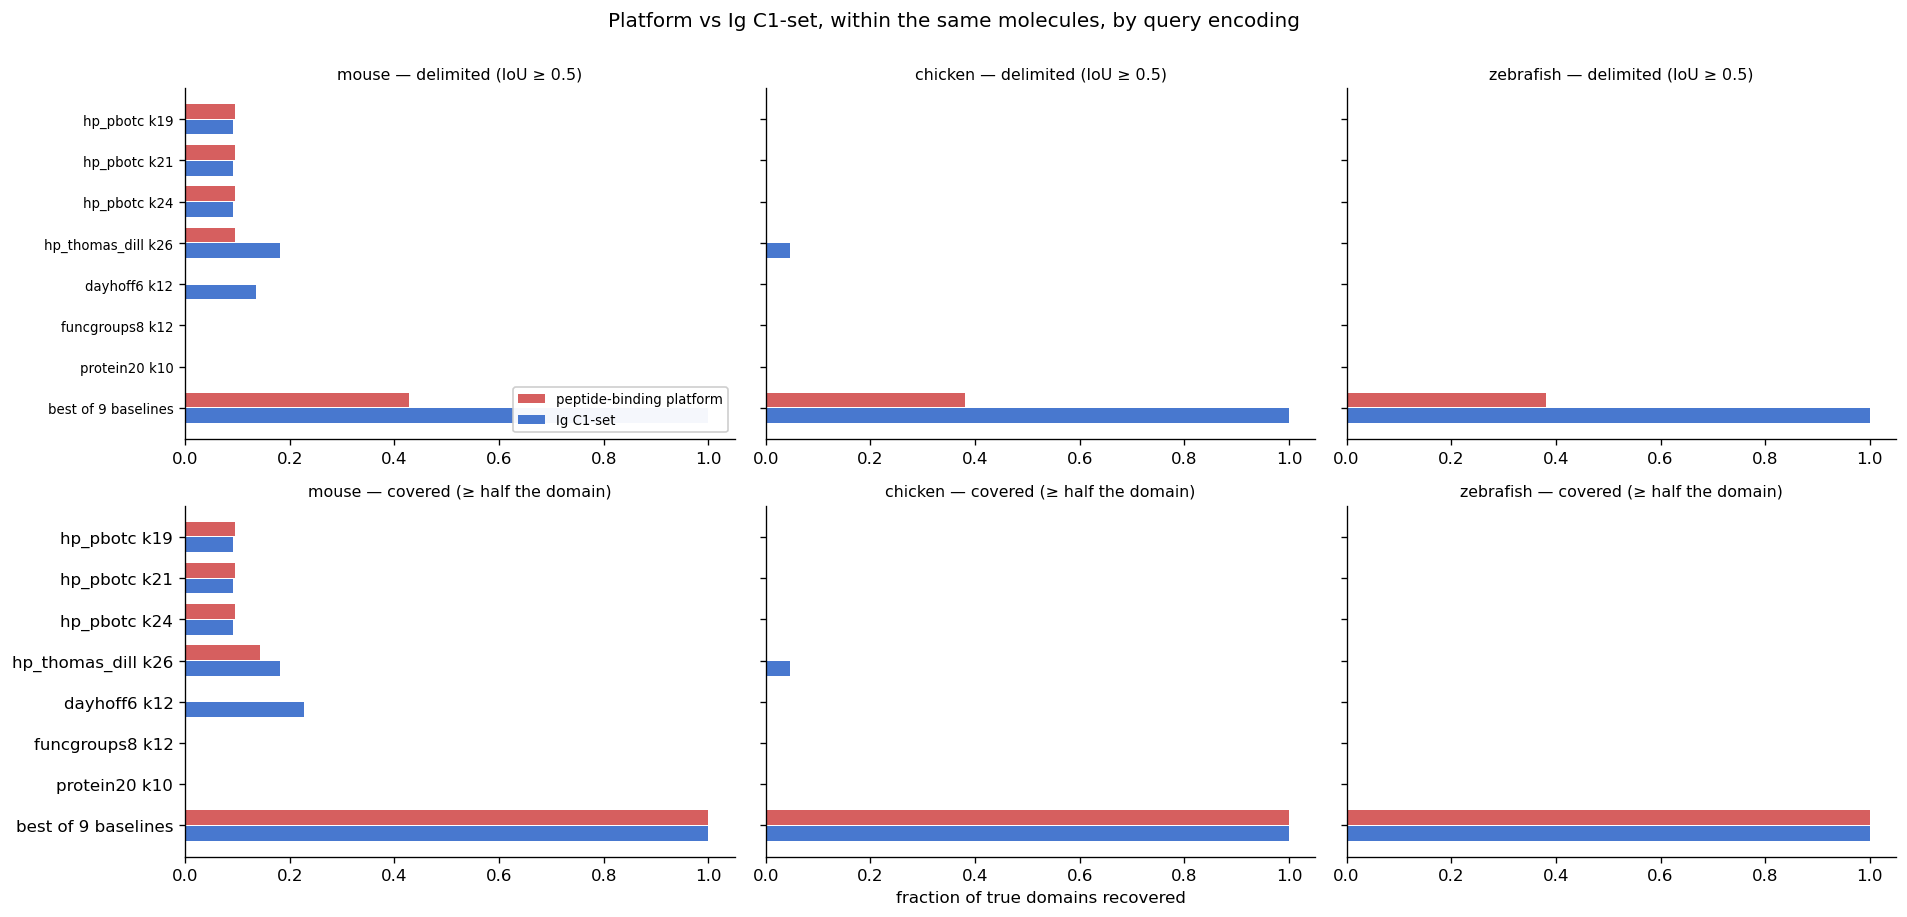

In [10]:
CORE = mu.core_truth()
G = mu.domain_grid(CORE, ["mouse", "chicken", "zebrafish"])
KM = [
    "hp_pbotc_1st_ed2_k19_lcTrue",
    "hp_pbotc_1st_ed2_k21_lcTrue",
    "hp_pbotc_1st_ed2_k24_lcTrue",
    "hp_thomas_dill2_k26_lcTrue",
    "dayhoff6_k12_lcTrue",
    "funcgroups8_k12_lcTrue",
    "protein20_k10_lcTrue",
]
KM_SHORT = {
    v: v.replace("_lcTrue", "")
    .replace("_1st_ed2", "")
    .replace("2_k", " k")
    .replace("_k", " k")
    for v in KM
}

N_PLAT = CORE.filter(pl.col("role") == "peptide-binding platform").height
N_IG = CORE.filter(pl.col("role") == "Ig C1-set").height

# Best of the nine baselines, taken per domain rather than per tool: the envelope of what
# any conventional method managed, which is the hardest reference to beat.
envelope = (
    G.filter(pl.col("tool") != "kmerseek")
    .group_by("species", "query_acc", "pfam_id", "role")
    .agg(best_iou=pl.col("best_iou").max(), best_cover=pl.col("best_cover").max())
    .with_columns(variant=pl.lit("best of 9 baselines"))
)
km = G.filter(pl.col("variant").is_in(KM)).select(
    "species", "query_acc", "pfam_id", "role", "best_iou", "best_cover", "variant"
)
both = pl.concat([km, envelope], how="diagonal_relaxed")

rows = []
for sp in ["mouse", "chicken", "zebrafish"]:
    for v in KM + ["best of 9 baselines"]:
        s = both.filter((pl.col("species") == sp) & (pl.col("variant") == v))
        pl_d = s.filter(
            (pl.col("role") == "peptide-binding platform") & (pl.col("best_iou") >= 0.5)
        ).height
        ig_d = s.filter(
            (pl.col("role") == "Ig C1-set") & (pl.col("best_iou") >= 0.5)
        ).height
        pl_c = s.filter(
            (pl.col("role") == "peptide-binding platform")
            & (pl.col("best_cover") >= 0.5)
        ).height
        ig_c = s.filter(
            (pl.col("role") == "Ig C1-set") & (pl.col("best_cover") >= 0.5)
        ).height
        rows.append(
            {
                "species": sp,
                "arm": v,
                "platform_delim": pl_d,
                "ig_delim": ig_d,
                "platform_cov": pl_c,
                "ig_cov": ig_c,
                "ratio_delim": (
                    round((pl_d / N_PLAT) / (ig_d / N_IG), 3) if ig_d else None
                ),
                "ratio_cov": (
                    round((pl_c / N_PLAT) / (ig_c / N_IG), 3) if ig_c else None
                ),
            }
        )
A1 = pl.DataFrame(rows)
print(f"denominators: {N_PLAT} platform domains, {N_IG} Ig C1-set domains, per species")
print("ratio = (platform recovered / 21) / (Ig recovered / 22); null where Ig is 0\n")
with pl.Config(tbl_rows=40, tbl_width_chars=180):
    print(A1)

fig, axes = plt.subplots(2, 3, figsize=(16, 7.6), sharey=True)
order = KM + ["best of 9 baselines"]
labels = [KM_SHORT.get(v, v) for v in order]
y = np.arange(len(order))
for j, sp in enumerate(["mouse", "chicken", "zebrafish"]):
    for i, (dcol, icol, title) in enumerate(
        [
            ("platform_delim", "ig_delim", "delimited (IoU ≥ 0.5)"),
            ("platform_cov", "ig_cov", "covered (≥ half the domain)"),
        ]
    ):
        ax = axes[i, j]
        s = A1.filter(pl.col("species") == sp)
        pv = [s.filter(pl.col("arm") == v)[dcol][0] / N_PLAT for v in order]
        iv = [s.filter(pl.col("arm") == v)[icol][0] / N_IG for v in order]
        ax.barh(
            y - 0.19,
            pv,
            0.36,
            color=mu.DOMAIN_ROLE_COLORS["peptide-binding platform"],
            label="peptide-binding platform",
        )
        ax.barh(
            y + 0.19,
            iv,
            0.36,
            color=mu.DOMAIN_ROLE_COLORS["Ig C1-set"],
            label="Ig C1-set",
        )
        ax.set_xlim(0, 1.05)
        ax.set_title(f"{sp} — {title}", fontsize=9.5)
        for s_ in ("right", "top"):
            ax.spines[s_].set_visible(False)
axes[0, 0].set_yticks(y)
axes[0, 0].set_yticklabels(labels, fontsize=8)
axes[0, 0].invert_yaxis()
axes[1, 1].set_xlabel("fraction of true domains recovered")
axes[0, 0].legend(fontsize=8, loc="lower right", framealpha=0.95)
fig.suptitle(
    "Platform vs Ig C1-set, within the same molecules, by query encoding", y=1.0
)
fig.tight_layout()
fig.savefig(FIG_DIR / "223_hp_vs_protein20_platform.png", dpi=200)

hit = (
    G.filter(
        (pl.col("tool") == "kmerseek")
        & pl.col("variant").is_in(KM)
        & (pl.col("n_calls") > 0)
    )
    .join(
        CORE.select("query_acc", "pfam_id", "hgnc_symbol"), on=["query_acc", "pfam_id"]
    )
    .select(
        "species",
        "variant",
        "hgnc_symbol",
        "pfam_id",
        "role",
        pl.col("best_iou").round(3),
        pl.col("best_cover").round(3),
        "n_calls",
    )
    .sort("species", "variant", "hgnc_symbol")
)
print(
    f"\nEvery core MHC domain any kmerseek arm reached at all (n = {hit.height} arm-domain cells):"
)
with pl.Config(tbl_rows=60, tbl_width_chars=180):
    print(hit)

The HP encoding beats the plain amino-acid encoding, and both lose badly to the baselines.

`protein20_k10` recovers **0 of the 51** core MHC domains in mouse — no platform, no Ig, no
ABC transporter. So does `funcgroups8_k12`. `dayhoff6_k12` recovers 3 Ig C1-set domains and
no platform. The four HP arms each recover a platform domain that `protein20` does not, and
`hp_thomas_dill2_k26` recovers 6 domains in total against `protein20`'s 0. On this set the
alphabet ordering is HP > dayhoff6 > funcgroups8 ≈ protein20, which is the direction the
hypothesis predicts.

The within-molecule ratio says the same thing more sharply. For the nine baselines pooled in
mouse, platform recovery relative to Ig recovery is 0.43 — they delimit every Ig domain and
under half the platforms. For `hp_pbotc_1st_ed2_k19` the ratio is 1.05: it recovers the
platform and the Ig domain at the same rate. The HP arm is not better at MHC. It is less
*biased against the platform*, which is a different and smaller claim.

Two things have to be said against it. First, the absolute numbers are tiny — 2 platform
domains out of 21, against 8 for the baselines — so this is a ratio between small counts and
one more or fewer domain moves it a lot. Second, the platform domains the HP arms recover are
HLA-DOA's PF00993 and HLA-DOB's PF00969 at IoU 0.60 and 0.71. No IoU-scored baseline delimits
HLA-DOA's platform at all, and the only one that reaches HLA-DOB's is MMseqs2
sequence-sequence, at IoU 0.50 against kmerseek's 0.71. That is real complementarity and it is
the only place in this notebook where kmerseek does something the IoU-scored baselines mostly
cannot, but it rests on two domains. Folddisco, scored on its own cover rule, reaches all 13
(§7).

Outside mouse the comparison runs out of data. In chicken one HP arm recovers one Ig domain
and nothing else; in zebrafish no kmerseek arm recovers any core MHC domain. There is no
cross-species trend here to report.

## 9. When kmerseek does land on a domain, is the boundary wrong at random?

Section 2 showed the baselines fail the IoU cut by overrunning the domain. That is a
statement about where a call's edges sit relative to the true edges, and the collapsed
domain table cannot answer it: it reports `qstart` as the minimum and `qend` as the maximum
over every call an arm made on that gene and family, which is a union of intervals rather
than one call.

So this section reads the raw call rows. For every call that carries a family the query
protein genuinely has and overlaps that domain by at least one residue, it measures
`qstart - true_start` and `qend - true_end` in residues. A call wider than the domain on
both sides is negative on the first and positive on the second.

One trap in the raw table has to be named, because it would invert the answer. `true_start`
is filled in only on calls the pipeline *assigned* to a truth instance, and assignment
already requires clearing IoU 0.5 (`assign_instances` in `evaluate_domain_calls.py`).
Selecting rows where `true_start` is present therefore selects the calls that passed, which
is the wrong sample for asking why calls fail. The truth table is joined on directly instead.

calls on a real domain of the right family, mouse, all 16 focus arms: 480_515
of those, flagged gray-zone (call mostly outside any annotation): 83_543 (17.4%)
Gray-zone status is not filtered here. It changes precision, never recall or
boundary geometry, and dropping those rows would remove the widest calls, which
are the ones the question is about.

Boundary error in residues, per arm (mouse, all 964 chr6 queries):
shape: (16, 9)
┌──────────────────────────────────────┬───────┬────────┬────────┬───┬────────┬─────────┬────────────────┬─────────┐
│ arm                                  ┆ n     ┆ ds_med ┆ ds_iqr ┆ … ┆ de_iqr ┆ med_abs ┆ frac_wide_both ┆ med_iou │
│ ---                                  ┆ ---   ┆ ---    ┆ ---    ┆   ┆ ---    ┆ ---     ┆ ---            ┆ ---     │
│ str                                  ┆ u32   ┆ f64    ┆ f64    ┆   ┆ f64    ┆ f64     ┆ f64            ┆ f64     │
╞══════════════════════════════════════╪═══════╪════════╪════════╪═══╪════════╪═════════╪════════

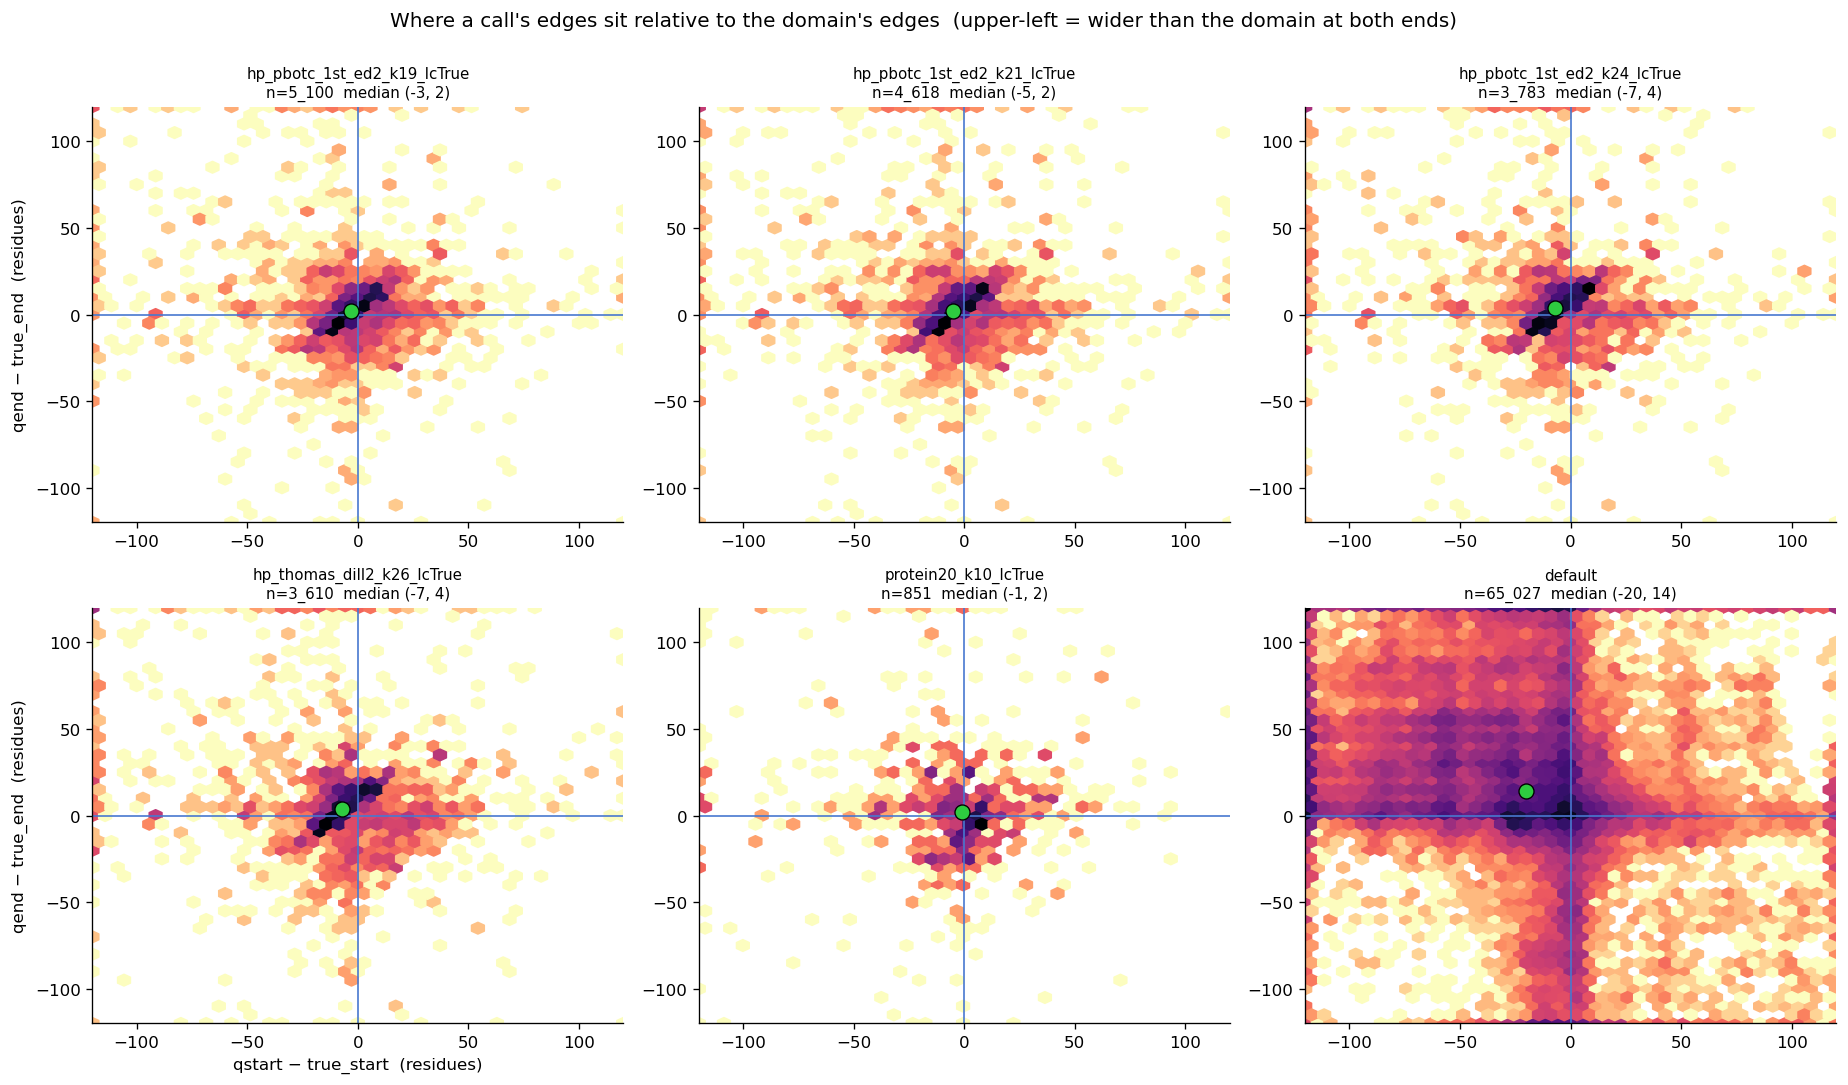

In [11]:
OFF_ARMS = [
    "kmerseek.hp_pbotc_1st_ed2_k19_lcTrue",
    "kmerseek.hp_pbotc_1st_ed2_k21_lcTrue",
    "kmerseek.hp_pbotc_1st_ed2_k24_lcTrue",
    "kmerseek.hp_thomas_dill2_k26_lcTrue",
    "kmerseek.protein20_k10_lcTrue",
    "hmmer3_phmmer.default",
]
off = mu.call_offsets("mouse")
print(
    f"calls on a real domain of the right family, mouse, all 16 focus arms: {off.height:_}"
)
print(
    f"of those, flagged gray-zone (call mostly outside any annotation): "
    f"{off['is_gray'].sum():_} ({off['is_gray'].mean():.1%})"
)
print("Gray-zone status is not filtered here. It changes precision, never recall or")
print("boundary geometry, and dropping those rows would remove the widest calls, which")
print("are the ones the question is about.\n")

stats = (
    off.group_by("arm")
    .agg(
        n=pl.len(),
        ds_med=pl.col("d_start").median(),
        ds_q1=pl.col("d_start").quantile(0.25),
        ds_q3=pl.col("d_start").quantile(0.75),
        de_med=pl.col("d_end").median(),
        de_q1=pl.col("d_end").quantile(0.25),
        de_q3=pl.col("d_end").quantile(0.75),
        med_abs=((pl.col("d_start").abs() + pl.col("d_end").abs()) / 2).median(),
        frac_wide_both=((pl.col("d_start") <= 0) & (pl.col("d_end") >= 0)).mean(),
        med_iou=pl.col("iou").median(),
    )
    .with_columns(
        ds_iqr=pl.col("ds_q3") - pl.col("ds_q1"),
        de_iqr=pl.col("de_q3") - pl.col("de_q1"),
        frac_wide_both=pl.col("frac_wide_both").round(3),
        med_iou=pl.col("med_iou").round(3),
    )
    .sort("med_abs")
)
print("Boundary error in residues, per arm (mouse, all 964 chr6 queries):")
with pl.Config(tbl_rows=20, tbl_width_chars=200, fmt_str_lengths=45):
    print(
        stats.select(
            "arm",
            "n",
            "ds_med",
            "ds_iqr",
            "de_med",
            "de_iqr",
            "med_abs",
            "frac_wide_both",
            "med_iou",
        )
    )

quad = (
    off.with_columns(
        quadrant=pl.when((pl.col("d_start") <= 0) & (pl.col("d_end") >= 0))
        .then(pl.lit("wide both ends"))
        .when((pl.col("d_start") > 0) & (pl.col("d_end") < 0))
        .then(pl.lit("narrow both ends"))
        .when((pl.col("d_start") > 0) & (pl.col("d_end") >= 0))
        .then(pl.lit("shifted C-ward"))
        .otherwise(pl.lit("shifted N-ward"))
    )
    .group_by("arm", "quadrant")
    .len()
)
qw = quad.pivot(on="quadrant", index="arm", values="len").fill_null(0)
qcols = [c for c in qw.columns if c != "arm"]
qw = qw.with_columns(total=pl.sum_horizontal(qcols))
qw = qw.with_columns([(pl.col(c) / pl.col("total")).round(3).alias(c) for c in qcols])
print("\nFraction of calls in each quadrant of the offset plane:")
with pl.Config(tbl_rows=20, tbl_width_chars=180, fmt_str_lengths=45):
    print(qw.sort("wide both ends", descending=True))

fig, axes = plt.subplots(2, 3, figsize=(15.5, 9.0))
LIM = 120
for ax, arm in zip(axes.ravel(), OFF_ARMS):
    s = off.filter(pl.col("arm") == arm)
    ax.hexbin(
        s["d_start"].to_numpy().clip(-LIM, LIM),
        s["d_end"].to_numpy().clip(-LIM, LIM),
        gridsize=42,
        bins="log",
        cmap="magma_r",
        mincnt=1,
    )
    ax.axhline(0, color="#4878CF", lw=1.0)
    ax.axvline(0, color="#4878CF", lw=1.0)
    r = stats.filter(pl.col("arm") == arm)
    ax.plot(
        r["ds_med"][0],
        r["de_med"][0],
        "o",
        ms=9,
        color="#2ECC40",
        markeredgecolor="black",
        markeredgewidth=0.8,
    )
    ax.set_title(
        f"{arm.split('.')[-1]}\nn={r['n'][0]:_}  median ({r['ds_med'][0]:.0f}, "
        f"{r['de_med'][0]:.0f})",
        fontsize=9,
    )
    ax.set_xlim(-LIM, LIM)
    ax.set_ylim(-LIM, LIM)
    for s_ in ("right", "top"):
        ax.spines[s_].set_visible(False)
axes[1, 0].set_xlabel("qstart − true_start  (residues)")
axes[0, 0].set_ylabel("qend − true_end  (residues)")
axes[1, 0].set_ylabel("qend − true_end  (residues)")
fig.suptitle(
    "Where a call's edges sit relative to the domain's edges  "
    "(upper-left = wider than the domain at both ends)",
    y=1.0,
)
fig.tight_layout()
fig.savefig(FIG_DIR / "223_boundary_offsets.png", dpi=200)

Boundary error against k, kmerseek arms only:
shape: (7, 8)
┌──────────────────┬─────┬──────┬────────┬────────┬────────┬────────┬─────────┐
│ alphabet         ┆ k   ┆ n    ┆ ds_med ┆ ds_iqr ┆ de_med ┆ de_iqr ┆ med_abs │
│ ---              ┆ --- ┆ ---  ┆ ---    ┆ ---    ┆ ---    ┆ ---    ┆ ---     │
│ str              ┆ i64 ┆ u32  ┆ f64    ┆ f64    ┆ f64    ┆ f64    ┆ f64     │
╞══════════════════╪═════╪══════╪════════╪════════╪════════╪════════╪═════════╡
│ protein20        ┆ 10  ┆ 851  ┆ -1.0   ┆ 28.0   ┆ 2.0    ┆ 30.0   ┆ 18.0    │
│ dayhoff6         ┆ 12  ┆ 1666 ┆ -3.0   ┆ 25.0   ┆ 1.0    ┆ 23.0   ┆ 14.0    │
│ funcgroups8      ┆ 12  ┆ 1159 ┆ -3.0   ┆ 31.0   ┆ 2.0    ┆ 31.0   ┆ 19.5    │
│ hp_pbotc_1st_ed2 ┆ 19  ┆ 5100 ┆ -3.0   ┆ 16.0   ┆ 2.0    ┆ 17.0   ┆ 9.0     │
│ hp_pbotc_1st_ed2 ┆ 21  ┆ 4618 ┆ -5.0   ┆ 17.0   ┆ 2.0    ┆ 19.0   ┆ 9.5     │
│ hp_pbotc_1st_ed2 ┆ 24  ┆ 3783 ┆ -7.0   ┆ 18.0   ┆ 4.0    ┆ 20.0   ┆ 11.0    │
│ hp_thomas_dill2  ┆ 26  ┆ 3610 ┆ -7.0   ┆ 19.0   ┆ 4.0    ┆

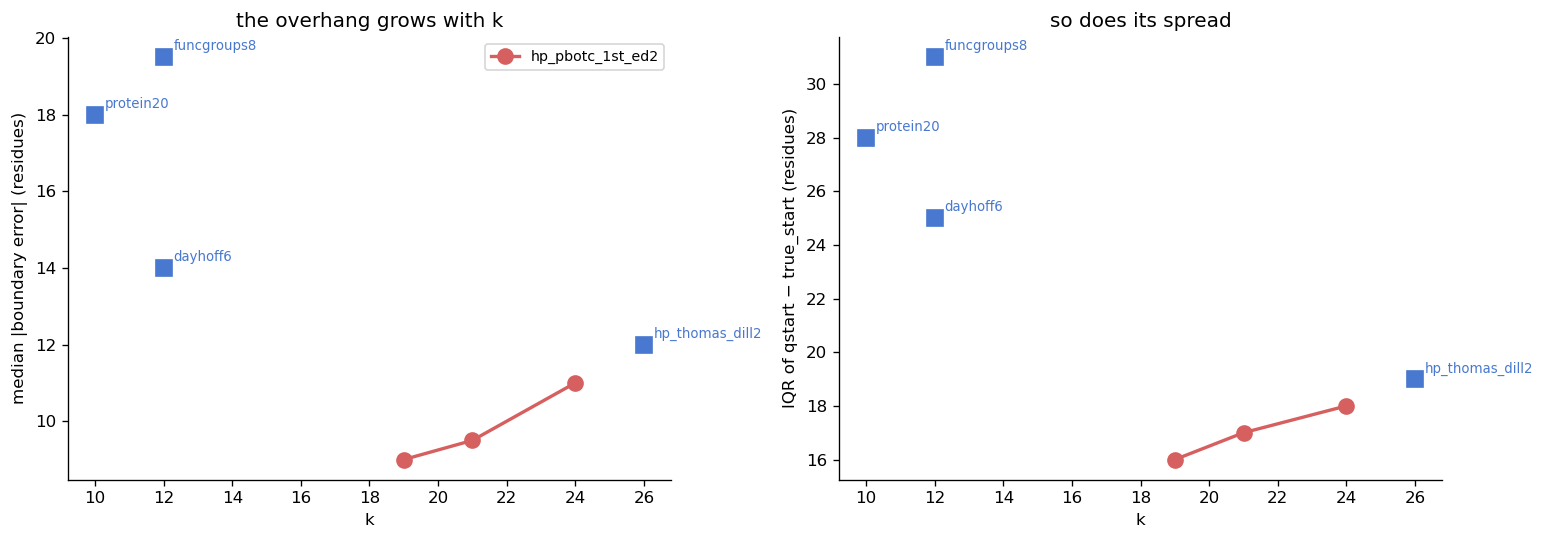

In [12]:
# Does the overhang scale with k? The four HP arms in the raw table cover k = 19, 21, 24, 26.
# k26 is a different alphabet (hp_thomas_dill2), so it is drawn but not fitted.
ks = (
    stats.filter(pl.col("arm").str.contains("kmerseek"))
    .with_columns(
        k=mu.arm_ksize(pl.col("arm")),
        alphabet=pl.col("arm")
        .str.replace("kmerseek.", "", literal=True)
        .str.replace(r"_k\d+_lcTrue", ""),
    )
    .sort("k")
)
print("Boundary error against k, kmerseek arms only:")
with pl.Config(tbl_rows=20, tbl_width_chars=180, fmt_str_lengths=45):
    print(
        ks.select(
            "alphabet", "k", "n", "ds_med", "ds_iqr", "de_med", "de_iqr", "med_abs"
        )
    )
same = ks.filter(pl.col("alphabet") == "hp_pbotc_1st_ed2").sort("k")
if same.height >= 2:
    slope = np.polyfit(same["k"].to_numpy(), same["med_abs"].to_numpy(), 1)[0]
    print(
        f"\nWithin hp_pbotc_1st_ed2 (k = {same['k'].to_list()}): median |offset| goes "
        f"{same['med_abs'].to_list()} residues, {slope:.2f} residues per unit k."
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
hp = ks.filter(pl.col("alphabet") == "hp_pbotc_1st_ed2")
other = ks.filter(pl.col("alphabet") != "hp_pbotc_1st_ed2")
for ax, (col, lab) in zip(
    axes,
    [
        ("med_abs", "median |boundary error| (residues)"),
        ("ds_iqr", "IQR of qstart − true_start (residues)"),
    ],
):
    ax.plot(
        hp["k"], hp[col], "o-", color="#D65F5F", lw=2, ms=9, label="hp_pbotc_1st_ed2"
    )
    for row in other.iter_rows(named=True):
        if row["k"] is None:
            continue
        ax.plot(row["k"], row[col], "s", ms=10, color="#4878CF")
        ax.annotate(
            row["alphabet"],
            (row["k"], row[col]),
            textcoords="offset points",
            xytext=(6, 4),
            fontsize=8,
            color="#4878CF",
        )
    ax.set_xlabel("k")
    ax.set_ylabel(lab)
    for s_ in ("right", "top"):
        ax.spines[s_].set_visible(False)
axes[0].legend(fontsize=8.5)
axes[0].set_title("the overhang grows with k")
axes[1].set_title("so does its spread")
fig.tight_layout()
fig.savefig(FIG_DIR / "223_offset_vs_ksize.png", dpi=200)

The offsets are structured, small, and they scale with k.

Every baseline is systematically wide. phmmer's median call starts 20 residues before the
domain and ends 14 after it, and 66% of its calls reach past the domain at both ends. The
structure tools are far worse: Folddisco's median call starts 120 residues early and ends 109
late, with 95% wide at both ends. That is the §2 failure mode measured directly — these
methods align whole proteins and then inherit the whole protein's extent as the domain call.

kmerseek is the tightest arm in the run. `hp_pbotc_1st_ed2_k19` has a median offset of −3 at
the start and +2 at the end, a median absolute boundary error of 9 residues, and only 24% of
its calls are wide at both ends. Its calls are spread roughly evenly across the four
quadrants rather than piled into the wide-both corner. The median IoU of a kmerseek call that
lands on a domain is 0.56, above the threshold; phmmer's is 0.42, below it.

The k-dependence is the mechanistic part. Within one alphabet, the median absolute boundary
error goes 9.0, 9.5, 11.0 residues at k = 19, 21, 24, and the start offset goes −3, −5, −7.
A region is assembled from matching k-mers, and a k-mer that overlaps the domain's first
residue can begin up to k−1 residues before it, so the reachable overhang is bounded by k and
grows with it. This is a known and characterisable boundary of the method, not noise: at
k = 19 it costs a handful of residues at each end.

This does not rescue kmerseek's recall. §8 showed it reaches very few MHC domains at all. But
it separates the two failures cleanly. kmerseek's problem in this run is getting to the right
family; once it gets there, it draws the tighter box.

## Summary

class I platform (PF00129)             delimited 8/8   covered 8/8   mean IoU 0.90
class II platform (PF00993/PF00969)    delimited 0/13   covered 13/13   mean IoU 0.38
Ig C1-set (PF07654)                    delimited 22/22   covered 22/22   mean IoU 0.96

kmerseek hp k19, mouse, core MHC domains delimited: 4/51
kmerseek protein20 k10, same: 0/51


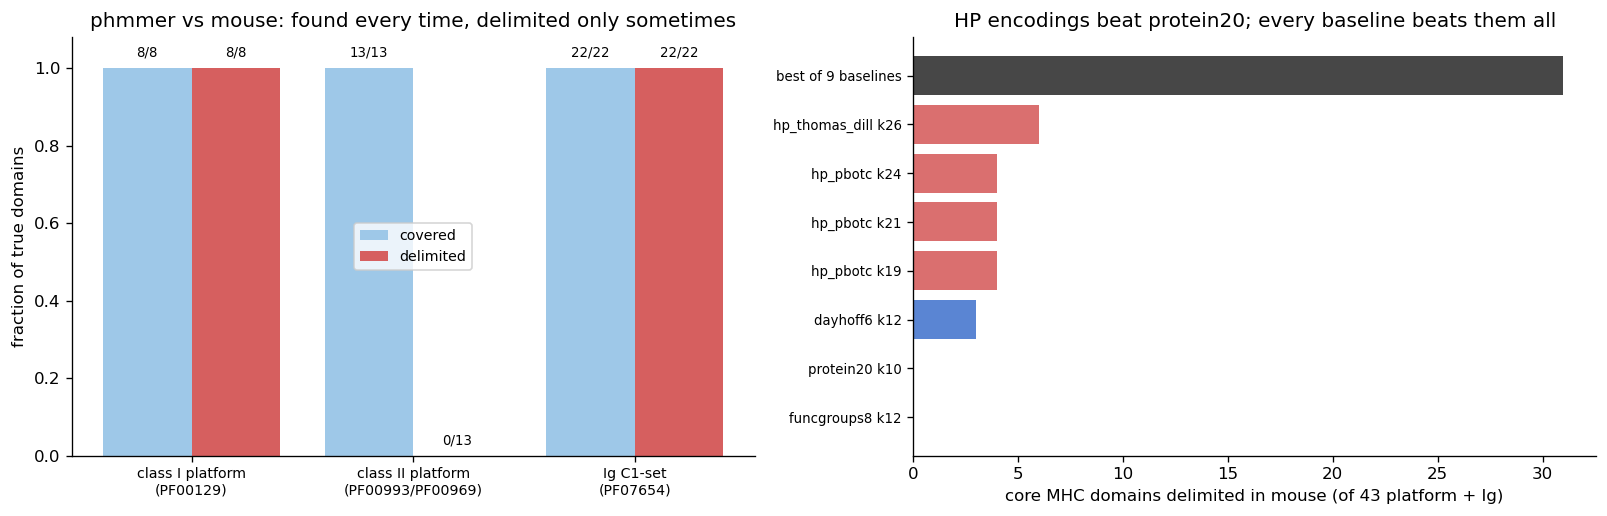

In [13]:
p = mouse.filter(pl.col("arm") == "hmmer3_phmmer.default")
GROUPS = [
    ("class I platform (PF00129)", pl.col("pfam_id") == "PF00129"),
    (
        "class II platform (PF00993/PF00969)",
        pl.col("pfam_id").is_in(["PF00993", "PF00969"]),
    ),
    ("Ig C1-set (PF07654)", pl.col("pfam_id") == "PF07654"),
]
srows = []
for label, expr in GROUPS:
    s = p.filter(expr)
    srows.append(
        {
            "group": label,
            "n": s.height,
            "delimited": int(s["found"].sum()),
            "covered": int((s["best_cover"] >= 0.5).sum()),
            "mean_iou": round(float(s["best_iou"].mean()), 3),
        }
    )
    print(
        f"{label:38s} delimited {srows[-1]['delimited']}/{s.height}   "
        f"covered {srows[-1]['covered']}/{s.height}   "
        f"mean IoU {srows[-1]['mean_iou']:.2f}"
    )
S = pl.DataFrame(srows)

k19 = both.filter(
    (pl.col("species") == "mouse")
    & (pl.col("variant") == "hp_pbotc_1st_ed2_k19_lcTrue")
)
p20 = both.filter(
    (pl.col("species") == "mouse") & (pl.col("variant") == "protein20_k10_lcTrue")
)
print(
    f"\nkmerseek hp k19, mouse, core MHC domains delimited: "
    f"{(k19['best_iou'] >= 0.5).sum()}/{k19.height}"
)
print(f"kmerseek protein20 k10, same: {(p20['best_iou'] >= 0.5).sum()}/{p20.height}")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
x = np.arange(S.height)
axes[0].bar(x - 0.2, S["covered"] / S["n"], 0.4, color="#9EC8E8", label="covered")
axes[0].bar(x + 0.2, S["delimited"] / S["n"], 0.4, color="#D65F5F", label="delimited")
axes[0].set_xticks(x)
axes[0].set_xticklabels([g.replace(" (", "\n(") for g in S["group"]], fontsize=8.5)
axes[0].set_ylabel("fraction of true domains")
axes[0].set_ylim(0, 1.08)
axes[0].set_title("phmmer vs mouse: found every time, delimited only sometimes")
axes[0].legend(fontsize=8.5)
for i, r in enumerate(S.iter_rows(named=True)):
    axes[0].text(
        i + 0.2,
        r["delimited"] / r["n"] + 0.03,
        f"{r['delimited']}/{r['n']}",
        ha="center",
        fontsize=8,
    )
    axes[0].text(
        i - 0.2,
        r["covered"] / r["n"] + 0.03,
        f"{r['covered']}/{r['n']}",
        ha="center",
        fontsize=8,
    )

ordering = (
    A1.filter(pl.col("species") == "mouse")
    .with_columns(total=pl.col("platform_delim") + pl.col("ig_delim"))
    .sort("total")
)
axes[1].barh(
    range(ordering.height),
    ordering["total"],
    color=[
        "#D65F5F" if "hp_" in a else ("#333333" if "baselines" in a else "#4878CF")
        for a in ordering["arm"]
    ],
    alpha=0.9,
)
axes[1].set_yticks(range(ordering.height))
axes[1].set_yticklabels([KM_SHORT.get(a, a) for a in ordering["arm"]], fontsize=8)
axes[1].set_xlabel("core MHC domains delimited in mouse (of 43 platform + Ig)")
axes[1].set_title("HP encodings beat protein20; every baseline beats them all")
for ax in axes:
    for s_ in ("right", "top"):
        ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "223_summary.png", dpi=200)

The within-molecule contrast does not say what it looks like it says, and that is the
result.

**Read off the run's default metric, the class II peptide-binding groove is invisible.** Eight
of the nine baseline tools recover 0 of the 13 class II platform domains in mouse, at 100 Mya,
while recovering 22 of 22 Ig C1-set domains in the same proteins on the same searches.
MMseqs2 in sequence-sequence mode is the single exception and recovers 1 of the 13.

**It is not a detection failure.** Those same calls cover the class II platform completely —
cover 1.0, IoU ≈ 0.4. The groove is found every time. What fails is the boundary, and it
fails because a full-length alignment cannot delimit a domain that occupies 40% of its
protein when the threshold is IoU 0.5.

**The cause is in the target database, not the tool.** A search inherits its boundary from
whatever it matched. The Ig C1-set can be delimited because 35 mouse proteins carry a C1-set
with no other Pfam domain beside it. The class II platforms are carried by 5 and 9 mouse
proteins respectively and **none** of them carries one alone — every instance sits next to a
C1-set. There is nothing in the database from which a tight class II boundary could be
learned.

**So the class I / class II gap is a Pfam modelling convention.** PF00129 covers α1+α2 as one
family and clears the threshold; PF00993 and PF00969 each cover half a platform and cannot.
Same fold, same function, opposite scores.

**One mechanism explains all of it, and the ablation says it is about target extent rather
than target architecture.** IoU of a full-length call is exactly the domain's length fraction,
so a domain is delimitable only if it fills half its protein (no MHC family does; PF00129 comes
closest at 0.49) or if some matched target's aligned extent stops near the domain's end.
Deleting the two mouse proteins that carry a class I platform with no other domain does **not**
collapse class I recall — it stays 8/8 for all nine tools, with the best phmmer IoU falling
from 0.90 to 0.67 as the call is inherited from a shorter class I chain instead. Deleting the
35 single-domain C1-set targets costs Foldseek 7 of 22, ProstT5 7 of 22 and Reseek 6 of 22, and
costs the five local sequence aligners nothing. Whole-chain structure aligners need a target
that *is* the domain; local sequence aligners can stop at the domain edge themselves.

**Folddisco confirms the metric artifact from outside.** It is the one arm the pipeline scores
on cover rather than IoU (`semantics = "motif" if job["tool"] == "folddisco"`). On the same
queries and the same targets it recovers 13 of 13 class II platforms where the eight IoU-scored
arms recover 1. Same domains, two rules, opposite answers, from a tool and a rule chosen by
someone else. It is kept out of every IoU ranking here, and the per-tool breakdown in §7 shows
that nothing in the pooled counts is carried by it.

**The HP encoding beats the plain amino-acid encoding, and both lose to the baselines.** On
the 51 core MHC domains in mouse, `protein20_k10` and `funcgroups8_k12` recover nothing at
all, `dayhoff6_k12` recovers 3 Ig domains and no platform, and the four HP arms recover 4 to
6 domains each including a class II platform. The two platform domains the HP arms recover are
HLA-DOA's PF00993 at IoU 0.60, which no IoU-scored baseline delimits, and HLA-DOB's PF00969 at
0.71, which only MMseqs2 sequence-sequence reaches and then only at IoU 0.50.
That is real complementarity resting on two domains, and it sits next to a much larger
absolute deficit: the baselines recover 32 to 34 of the 51.

**kmerseek's boundaries are the tightest in the run.** Measured per call, on every call that
lands on a real domain of the right family in mouse: `hp_pbotc_1st_ed2_k19` has a median
boundary error of 9 residues and 24% of its calls overrun the domain at both ends. phmmer's
median error is 34 residues with 66% overrunning; Folddisco's is 188 residues with 95%
overrunning. The median IoU of a kmerseek call that reaches a domain is 0.56, above the
threshold, against phmmer's 0.42. Whatever is wrong with kmerseek in this run, it is not the
fenceline.

**The overhang scales with k, which makes it characterisable.** Within `hp_pbotc_1st_ed2`,
median absolute boundary error goes 9.0, 9.5, 11.0 residues at k = 19, 21, 24 and the start
offset goes −3, −5, −7. A region is assembled from matching k-mers and a k-mer overlapping
the domain's first residue can begin up to k−1 residues before it, so the overhang is bounded
by k. This is a known limit of the method with a known size, not unstructured error.

**What this means for anything quoted off this run.** Domain-level recall at IoU ≥ 0.5 is a
boundary metric, not a homology metric, and for short domains inside multi-domain proteins
the two come apart completely. Every MHC recall number in notebooks 221 and 222 carries this,
and so does the kmerseek-versus-baseline gap in 221 §1 — which is the same failure mode, one
step further along. Notebook
[224](./224_detect_vs_delimit_and_the_annotation_floor.ipynb) takes the decomposition to the
whole region and to all nine species.